# Network Extension: Cyberwarfare Game on Graphs

This notebook extends the thesis model from a single attacker–defender payoff matrix to a network of cyber targets. Each node represents a strategically relevant location in the cyber battlefield, and each node keeps its own local payoff structure. The purpose is to test how equilibrium behavior changes once cyber conflict is no longer treated as one isolated target.

The notebook focuses on four experiments:

| Cell | Experiment | Topology | Spillover |
|------|------------|----------|-----------|
| 1 | Core functions and node-specific payoff matrices | — | — |
| 2 | **Experiment 1**: 3-node baseline | Full clique | None |
| 3 / 3b | **Experiment 2**: 5-node system | Hub-and-spoke | None |
| 4a / 4b | **Experiment 3**: 3-node clique | No spillover → full spillover |
| 5a / 5b | **Experiment 4**: 5-node hub-and-spoke | No spillover → full spillover |

The main thesis question is whether network position changes strategic value. In the single-location model, strategy depends only on the local payoff matrix. In the network model, a node's relevance also depends on its position in the graph and on whether actions at one location propagate to neighboring locations.

**Nodes used in the 5-node model:** N0 Military C2 · N1 Power Grid · N2 Telecoms · N3 SWIFT/Bank · N4 Nuclear/SCADA.


In [ ]:
"""
CELL 1 — CORE FUNCTIONS AND SHARED MODEL SETUP
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from itertools import product

# ── Shared style ───────────────────────────────────────────────────────────────
BG, CARD, BORDER = '#0b0e1a', '#13172a', '#252d4a'
WHITE, MUTED     = '#eef0ff', '#9098bb'
ATT_COL, DEF_COL = '#e05c6e', '#4ec9a0'
PAY_A,   PAY_D   = '#7da9f5', '#f5c97d'

NODE_RINGS = ['#4a7cdc','#3dba80','#dc4a7c','#dcb44a','#9b4adc','#4adcce','#dc7c4a','#4adca0']
NODE_FILLS = ['#152240','#152e22','#2e1522','#2e2415','#221536','#152e2e','#2e2015','#152e24']
NODE_LBLS  = ['#7aadff','#5de0a0','#ff7aad','#ffd07a','#c07aff','#7affd0','#ffa07a','#7affa0']
ACTION_NAMES  = ['A0','A1','A2']
DEFENSE_NAMES = ['D0','D1','D2']

def style_ax(ax):
    """Apply dark background style to a regular axes."""
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_color(BORDER)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)


# ══ 1. BASE PAYOFF (unchanged from thesis) ════════════════════════════════════
def get_base_payoff(a, d):
    return np.array([[0.,4.,6.],[5.,-1.,1.],[2.,6.,-12.]])[a, d]


# ══ 2. JOINT PAYOFF MATRIX ════════════════════════════════════════════════════
# NOTE: build_joint_payoff_matrix is defined below alongside the node-specific
# matrices it uses.  It replaces the shared get_base_payoff() with
# get_node_payoff(node_idx, a, d) so each location has its own economics.


# ══ 3. FICTITIOUS PLAY (same algorithm as thesis, larger matrix) ══════════════
def run_fictitious_play(PM, iterations=5000):
    n = PM.shape[0]
    att_c, def_c = np.ones(n), np.ones(n)
    for _ in range(iterations):
        ab = att_c / att_c.sum();  db = def_c / def_c.sum()
        att_c[np.argmax(PM   @ db)] += 1
        def_c[np.argmin(PM.T @ ab)] += 1
    return att_c / att_c.sum(), def_c / def_c.sum()


# ══ 4. MARGINALS (collapse joint dist per-node probs) ══════════════════════
def get_marginals(dist, profiles, n_nodes):
    marg = np.zeros((n_nodes, 3))
    for idx, prof in enumerate(profiles):
        for node in range(n_nodes):
            marg[node, prof[node]] += dist[idx]
    return marg


# ══ 5. WRAPPER — run one complete experiment ══════════════════════════════════
def run_experiment(n_nodes, alpha_att=0.0, alpha_def=0.0,
                   p_edge=0.6, seed=42, iterations=5000,
                   adjacency=None, weights=None):
    if weights is None:
        raw = np.array([1.0/(i+1)**0.7 for i in range(n_nodes)])
        weights = raw / raw.sum() * n_nodes
    if adjacency is None:
        np.random.seed(seed)
        A = np.zeros((n_nodes, n_nodes), int)
        for i in range(n_nodes):
            for j in range(i+1, n_nodes):
                if np.random.rand() < p_edge: A[i,j] = A[j,i] = 1
        for i in range(n_nodes):
            if A[i].sum() == 0:
                j = (i+1) % n_nodes; A[i,j] = A[j,i] = 1
        adjacency = A
    PM, profiles = build_joint_payoff_matrix(n_nodes, adjacency, weights, alpha_att, alpha_def)
    att_dist, def_dist = run_fictitious_play(PM, iterations)
    att_marg = get_marginals(att_dist, profiles, n_nodes)
    def_marg = get_marginals(def_dist, profiles, n_nodes)
    att_pay = np.zeros(n_nodes); def_pay = np.zeros(n_nodes)
    for i, ap in enumerate(profiles):
        for j, dp in enumerate(profiles):
            wij = att_dist[i] * def_dist[j]
            for node in range(n_nodes):
                local = weights[node] * get_base_payoff(ap[node], dp[node])
                sa = sum(alpha_att * weights[nb] * get_base_payoff(ap[nb], dp[node])
                         for nb in range(n_nodes) if adjacency[node,nb])
                sd = sum(alpha_def * weights[node] * get_base_payoff(ap[node], dp[nb])
                         for nb in range(n_nodes) if adjacency[node,nb])
                v = local + sa + sd
                att_pay[node] += wij * v
                def_pay[node] -= wij * v
    return dict(n_nodes=n_nodes, weights=weights, adjacency=adjacency,
                profiles=profiles, att_dist=att_dist, def_dist=def_dist,
                att_marg=att_marg, def_marg=def_marg,
                att_pay=att_pay, def_pay=def_pay,
                alpha_att=alpha_att, alpha_def=alpha_def)


# ══ 6. REUSABLE NODE-PANEL DRAWING ═══════════════════════════════════════════
def draw_node_panel(ax, node_idx, name, weight, att_marg, def_marg,
                    att_pay, def_pay, panel_x, panel_y, pw=0.30, lg=0.055):
    """Draw a styled info card for one node onto axes ax."""
    ci = node_idx % len(NODE_RINGS)
    ph = lg * 5.2
    ax.add_patch(mpatches.FancyBboxPatch(
        (panel_x, panel_y - ph), pw, ph,
        boxstyle='round,pad=0.012', facecolor=CARD,
        edgecolor=NODE_RINGS[ci], lw=1.0, zorder=4, alpha=0.95))
    ax.text(panel_x + pw/2, panel_y - lg*0.1,
            f'Node {name}  ·  w = {weight:.2f}',
            fontsize=9, fontweight='bold', color=NODE_LBLS[ci],
            ha='center', va='top', zorder=6)
    ax.plot([panel_x+0.01, panel_x+pw-0.01], [panel_y-lg*0.85]*2,
            color=BORDER, lw=0.8, zorder=6)
    p = att_marg[node_idx]; q = def_marg[node_idx]
    da = ACTION_NAMES[np.argmax(p)]; dd = DEFENSE_NAMES[np.argmax(q)]
    ax.text(panel_x+0.01, panel_y-lg*1.05,
            f'Dominant:  {da}  ·  {dd}',
            fontsize=8.5, fontweight='bold', color=ATT_COL,
            ha='left', va='top', zorder=6)
    ax.text(panel_x+0.01, panel_y-lg*2.0,
            f'Att  p\u2080={p[0]:.3f}  p\u2081={p[1]:.3f}  p\u2082={p[2]:.3f}',
            fontsize=7.8, color=ATT_COL, ha='left', va='top',
            zorder=6, fontfamily='monospace')
    ax.text(panel_x+0.01, panel_y-lg*2.95,
            f'Def  q\u2080={q[0]:.3f}  q\u2081={q[1]:.3f}  q\u2082={q[2]:.3f}',
            fontsize=7.8, color=DEF_COL, ha='left', va='top',
            zorder=6, fontfamily='monospace')
    ax.plot([panel_x+0.01, panel_x+pw-0.01], [panel_y-lg*3.55]*2,
            color=BORDER, lw=0.8, zorder=6)
    ax.text(panel_x+0.01, panel_y-lg*3.75,
            f'E[U] Att  =  {att_pay[node_idx]:+.4f}',
            fontsize=8.5, color=PAY_A, fontstyle='italic',
            ha='left', va='top', zorder=6)
    ax.text(panel_x+0.01, panel_y-lg*4.50,
            f'E[U] Def  =  {def_pay[node_idx]:+.4f}',
            fontsize=8.5, color=PAY_D, fontstyle='italic',
            ha='left', va='top', zorder=6)


print('Core modules loaded.')
print('Base payoff matrix (attacker):')
for a in range(3):
    print(f'  A{a}: {[get_base_payoff(a,d) for d in range(3)]}')


# ══ 6. NODE CATALOGUE — real cyberwarfare targets, ordered by rank 
NODE_CATALOGUE = {
    # key: (short_label, long_label, rank)
    0: ('N0', 'Military C2',         1),
    1: ('N1', 'Power Grid',          2),
    2: ('N2', 'Telecoms (hub)',       3),
    3: ('N3', 'SWIFT/Bank',          4),
    4: ('N4', 'Nuclear/SCADA',       5),
    5: ('N5', 'Water/SCADA',         6),
    6: ('N6', 'Transport/Logistics', 7),
    7: ('N7', 'Healthcare Systems',  8),
}

def hub_adjacency(n_nodes):
    """
    Build structured hub-and-spoke adjacency for n nodes (3–8).
    Rule (motivated by real attack doctrine):
      • N2 (Telecoms) connects to EVERY other node — it is the hub.
      • N1 (Power Grid) connects to all nodes that physically need
        electricity: C2, Telecoms, SWIFT, Water, Transport, Healthcare.
        Does NOT connect to Nuclear (air-gapped) or itself.
      • All other nodes connect to Telecoms and Power only,
        EXCEPT Nuclear (N4) which connects to Telecoms only
        (Stuxnet — only digital vector is the comms monitoring system).
      • N3 (SWIFT) ↔ N4 (Nuclear): NOT connected (logistical only,
        excluded per Option A — direct dependencies only).
    Returns binary integer numpy array.
    """
    A = np.zeros((n_nodes, n_nodes), int)
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i == j:
                continue
            # Telecoms (N2) is hub — connects to everyone
            if i == 2 or j == 2:
                A[i, j] = 1
            # Power (N1) connects to all except Nuclear (N4)
            elif (i == 1 or j == 1) and 4 not in (i, j):
                A[i, j] = 1
    return A

def clique_adjacency(n_nodes):
    """Full clique — every node connects to every other."""
    return 1 - np.eye(n_nodes, dtype=int)

def node_labels(n_nodes):
    """Return (short, long) lists for n nodes from the catalogue."""
    shorts = [NODE_CATALOGUE[i][0] for i in range(n_nodes)]
    longs  = [NODE_CATALOGUE[i][1] for i in range(n_nodes)]
    return shorts, longs

def power_law_weights(n_nodes, beta=0.7):
    raw = np.array([1.0/(i+1)**beta for i in range(n_nodes)])
    return raw / raw.sum() * n_nodes


# ══ 7. REUSABLE NETWORK FIGURE DRAWER ════════════════════════════════════════
def draw_network_figure(result, title, subtitle, edge_color=None,
                        node_short=None, node_long=None):
    """
    Draw a clean circular network diagram with guaranteed non-overlapping panels.
    Nodes on inner circle (r=0.38), panels on outer ring (r=0.80).
    Works for any n from 3 to 8.
    """
    n  = result['n_nodes']
    w  = result['weights']
    aj = result['adjacency']
    ap = result['att_marg']
    dp = result['def_marg']
    if edge_color is None: edge_color = BORDER
    if node_short is None: node_short = [f'N{i}' for i in range(n)]
    if node_long  is None: node_long  = [f'Node {i}' for i in range(n)]

    max_w   = max(w)
    CIRC_R  = 0.38
    PANEL_R = 0.80
    PW      = 0.40
    PH      = 0.38
    angles  = np.linspace(np.pi/2, np.pi/2+2*np.pi, n, endpoint=False)
    node_xy = {i:(CIRC_R*np.cos(angles[i]), CIRC_R*np.sin(angles[i])) for i in range(n)}
    node_r  = {i:0.060+0.040*(w[i]/max_w) for i in range(n)}

    fig, ax = plt.subplots(figsize=(16, 13))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.set_xlim(-1,1); ax.set_ylim(-1,1)
    ax.set_aspect('equal'); ax.axis('off')
    fig.suptitle(f'{title}\n{subtitle}',
                 fontsize=12, fontweight='bold', color=WHITE, y=0.97)

    # edges
    for i in range(n):
        for j in range(i+1, n):
            if aj[i,j]:
                x0,y0=node_xy[i]; x1,y1=node_xy[j]
                dx,dy=x1-x0,y1-y0; d_=np.sqrt(dx**2+dy**2); ux,uy=dx/d_,dy/d_
                lw = 0.8+1.6*(w[i]+w[j])/(2*max_w)
                ax.plot([x0+ux*node_r[i],x1-ux*node_r[j]],
                        [y0+uy*node_r[i],y1-uy*node_r[j]],
                        color=edge_color, lw=lw, linestyle='--',
                        alpha=0.65, zorder=1)

    # nodes
    for i in range(n):
        x,y=node_xy[i]; R=node_r[i]; ci=i%len(NODE_RINGS)
        ax.add_patch(plt.Circle((x,y),R+0.013,color=NODE_RINGS[ci],alpha=0.15,zorder=2))
        ax.add_patch(plt.Circle((x,y),R,color=NODE_FILLS[ci],zorder=3))
        ax.add_patch(plt.Circle((x,y),R,fill=False,
                                  edgecolor=NODE_RINGS[ci],lw=2.2,zorder=4))
        fs=max(8,int(8+5*(w[i]/max_w)))
        ax.text(x,y+R*0.18,node_short[i],fontsize=fs,fontweight='bold',
                color=NODE_LBLS[ci],ha='center',va='center',zorder=5)
        ax.text(x,y-R*0.40,f'w={w[i]:.2f}',fontsize=7,
                color=NODE_LBLS[ci],alpha=0.9,ha='center',va='center',zorder=5)

    # panels — fixed outer ring, guaranteed no overlap
    for i in range(n):
        ci  = i%len(NODE_RINGS)
        pcx = PANEL_R*np.cos(angles[i])
        pcy = PANEL_R*np.sin(angles[i])
        px0 = pcx-PW/2; py1 = pcy+PH/2

        ax.add_patch(mpatches.FancyBboxPatch(
            (px0,py1-PH),PW,PH,
            boxstyle='round,pad=0.012',facecolor=CARD,
            edgecolor=NODE_RINGS[ci],lw=1.0,zorder=6,alpha=0.96))

        p_=ap[i]; q_=dp[i]
        da=ACTION_NAMES[np.argmax(p_)]; dd=DEFENSE_NAMES[np.argmax(q_)]
        tx=px0+0.014; row=py1-0.030; gap=PH/6.5

        lbl = f'{node_short[i]}: {node_long[i][:16]}'
        ax.text(px0+PW/2, py1-0.008, lbl,
                fontsize=8, fontweight='bold', color=NODE_LBLS[ci],
                ha='center',va='top',zorder=7)
        ax.plot([px0+0.014,px0+PW-0.014],[row-0.002]*2,
                color=BORDER,lw=0.8,zorder=7)
        row -= gap*0.5

        ax.text(tx,row,f'w={w[i]:.3f}  ·  Dominant: {da}/{dd}',
                fontsize=7.5,fontweight='bold',color=ATT_COL,
                ha='left',va='top',zorder=7)
        row -= gap

        ax.text(tx,row,
                f'Att  p\u2080={p_[0]:.3f}  p\u2081={p_[1]:.3f}  p\u2082={p_[2]:.3f}',
                fontsize=7,color=ATT_COL,ha='left',va='top',
                zorder=7,fontfamily='monospace')
        row -= gap

        ax.text(tx,row,
                f'Def  q\u2080={q_[0]:.3f}  q\u2081={q_[1]:.3f}  q\u2082={q_[2]:.3f}',
                fontsize=7,color=DEF_COL,ha='left',va='top',
                zorder=7,fontfamily='monospace')
        row -= gap*0.75
        ax.plot([px0+0.014,px0+PW-0.014],[row]*2,color=BORDER,lw=0.8,zorder=7)
        row -= gap*0.55

        ax.text(tx,row,f'E[U] Att  =  {result["att_pay"][i]:+.4f}',
                fontsize=7.5,color=PAY_A,fontstyle='italic',
                ha='left',va='top',zorder=7)
        row -= gap*0.9

        ax.text(tx,row,f'E[U] Def  =  {result["def_pay"][i]:+.4f}',
                fontsize=7.5,color=PAY_D,fontstyle='italic',
                ha='left',va='top',zorder=7)

        # dotted connector: node edge nearest panel edge
        nx,ny=node_xy[i]
        ddx,ddy=pcx-nx,pcy-ny; d_=np.sqrt(ddx**2+ddy**2)
        sx=nx+node_r[i]*ddx/d_; sy=ny+node_r[i]*ddy/d_
        ex=np.clip(nx,px0,px0+PW); ey=np.clip(ny,py1-PH,py1)
        ax.plot([sx,ex],[sy,ey],color=NODE_RINGS[ci],
                lw=0.8,linestyle=':',alpha=0.6,zorder=5)

    return fig


# ══ 8. REUSABLE PAYOFF BAR CHART ══════════════════════════════════════════════
def draw_payoff_bars(results_list, case_labels, case_colors,
                     node_short, node_long, w, title):
    """
    One subplot per node, grouped bars across conditions.
    """
    n       = len(node_short)
    n_cases = len(results_list)
    x_idx   = np.arange(n_cases)
    wd      = 0.30

    fig, axes = plt.subplots(1, n, figsize=(5*n, 7), sharey=False)
    if n == 1: axes = [axes]
    fig.patch.set_facecolor(BG)
    fig.suptitle(title, fontsize=12, fontweight='bold', color=WHITE, y=1.01)

    for col, ax in enumerate(axes):
        style_ax(ax)
        ci       = col % len(NODE_RINGS)
        att_vals = [r['att_pay'][col] for r in results_list]
        def_vals = [r['def_pay'][col] for r in results_list]

        b_a = ax.bar(x_idx-wd/2, att_vals, wd,
                     color=ATT_COL, alpha=0.85, label='Attacker')
        b_d = ax.bar(x_idx+wd/2, def_vals, wd,
                     color=DEF_COL, alpha=0.85, label='Defender')
        ax.axhline(0, color=MUTED, lw=0.9, linestyle='--', alpha=0.5)
        ax.set_xticks(x_idx)
        ax.set_xticklabels(case_labels, fontsize=8, rotation=20,
                            ha='right', color=MUTED)
        for tick, col_ in zip(ax.get_xticklabels(), case_colors):
            tick.set_color(col_)
        ax.set_title(f'{node_short[col]}: {node_long[col]}\n(w={w[col]:.3f})',
                     fontsize=9, fontweight='bold',
                     color=NODE_LBLS[col%len(NODE_LBLS)], pad=8)
        ax.set_ylabel('Expected Payoff', color=MUTED, fontsize=9)
        ax.grid(axis='y', color=BORDER, lw=0.6, alpha=0.5)

        y_rng = max(abs(v) for v in att_vals+def_vals) or 1
        off   = y_rng*0.05+0.15
        for bar,val in zip(b_a,att_vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    val+(off if val>=0 else -off*1.5),
                    f'{val:+.2f}',ha='center',fontsize=8,
                    color=ATT_COL,fontweight='bold')
        for bar,val in zip(b_d,def_vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    val-(off if val<=0 else -off*1.5),
                    f'{val:+.2f}',ha='center',fontsize=8,
                    color=DEF_COL,fontweight='bold')
        if col == n-1:
            ax.legend(facecolor=CARD,edgecolor=BORDER,
                      labelcolor=WHITE,fontsize=9,loc='upper left')
    plt.tight_layout()
    return fig


print('Core modules + helpers loaded.')
print(f'   Node catalogue: {len(NODE_CATALOGUE)} targets defined (N0–N7)')
print(f'   hub_adjacency(5):\n{hub_adjacency(5)}')
print(f'   clique_adjacency(3):\n{clique_adjacency(3)}')



# ══ NODE-SPECIFIC PAYOFF MATRICES ════════════════════════════════════════════
# Each node has its own 3×3 attacker payoff matrix reflecting the real-world
# economics of attacking and defending that specific infrastructure target.
# Structure: U[a,d] where rows=attacker actions {A0,A1,A2}, cols=defender {D0,D1,D2}
# Derived from parametric model: U = make_matrix(w1,w2,ca1,ca2,cd1,cd2)
# All matrices have valid full-support mixed Nash equilibria.

NODE_PAYOFF_MATRICES = {
    # N0 Military C2 — high attack cost (low ca1 reward, high cd2)
    # Nash: A0(0.775)/D2(0.800) — attacker cautious, defender maximally invested
    # Rationale: C2 networks are heavily monitored; even moderate attacks risk
    #            detection; defender cannot afford anything less than full hardening
    'N0': np.array([[ 0.,  1.,  3.],   # A0: no attack
                    [ 7.,  0.,  2.],   # A1: moderate — barely worth it vs D1/D2
                    [16., 17., -1.]],  # A2: high — huge reward vs D0 but costly
                   dtype=float),

    # N1 Power Grid — accessible SCADA, moderate attack has best ROI
    # Nash: A1(0.500)/D1(0.500) — genuinely contested, both sides moderate
    # Rationale: SCADA systems are reachable but detection exists; A1 probes
    #            without full commitment; defender matches with moderate investment
    'N1': np.array([[ 0.,  4.,  5.],   # A0: pass
                    [ 7.,  3.,  4.],   # A1: moderate — positive across all D
                    [ 6., 10., -5.]],  # A2: high — risky against D2
                   dtype=float),

    # N2 Telecoms hub — contested middle ground, defender leans moderate
    # Nash: A0(0.500)/D1(0.350) — balanced, slightly D1-dominant for defender
    # Rationale: distributed infrastructure makes both attack and defense moderate;
    #            hub position means defender cannot ignore any level
    'N2': np.array([[ 0.,  4.,  6.],   # A0: pass
                    [ 7.,  1.,  3.],   # A1: moderate
                    [ 7., 11., -7.]],  # A2: high — very risky
                   dtype=float),

    # N3 SWIFT/Bank — low attack entry cost, defender must fortify strongly
    # Nash: A1(0.600)/D2(0.778) — attacker exploits easy entry, defender responds
    # Rationale: financial systems have many interfaces (low ca1); once breached
    #            damage is severe; defender must invest heavily (D2)
    'N3': np.array([[ 0.,  6., 10.],   # A0: pass — but defender costs high
                    [ 8.,  4.,  8.],   # A1: dominant — positive even vs D1/D2
                    [14., 20.,  6.]],  # A2: also viable — high reward
                   dtype=float),

    # N4 Nuclear SCADA — prohibitive attack cost, maximum hardening needed
    # Nash: A0(0.762)/D2(0.786) — attacker deterred, defender fully committed
    # Rationale: Stuxnet required years of preparation; most attack attempts fail;
    #            but defender must maintain max hardening precisely because the
    #            consequence of breach is catastrophic
    'N4': np.array([[ 0.,  1.,  2.],   # A0: pass — very low cost to defend
                    [ 5.,  0.,  1.],   # A1: barely positive vs D0 only
                    [11., 12., -1.]],  # A2: high risk/reward ratio
                   dtype=float),
}

def get_node_payoff(node_idx, a, d):
    """Return attacker payoff at node_idx for action pair (a,d)."""
    key = f'N{node_idx}'
    if key in NODE_PAYOFF_MATRICES:
        return NODE_PAYOFF_MATRICES[key][a, d]
    # Fallback to shared matrix for node indices > 4
    return get_base_payoff(a, d)


# ══ UPDATED JOINT PAYOFF MATRIX (node-specific) ═══════════════════════════════
def build_joint_payoff_matrix(n_nodes, adjacency, weights,
                               alpha_att=0.0, alpha_def=0.0):
    """
    Build the (3^n × 3^n) attacker payoff matrix using NODE-SPECIFIC base payoffs.
    Each node i uses NODE_PAYOFF_MATRICES[N{i}] as its base 3×3 matrix.
    Payoff at node i:
        w_i · U_i[a_i, d_i]
        + alpha_att · Σ_{j∈N(i)} w_j · U_j[a_j, d_i]
        + alpha_def · Σ_{j∈N(i)} w_i · U_i[a_i, d_j]
    """
    profiles = list(product(range(3), repeat=n_nodes))
    n_joint  = len(profiles)
    PM       = np.zeros((n_joint, n_joint))
    for i, ap in enumerate(profiles):
        for j, dp in enumerate(profiles):
            total = 0.0
            for node in range(n_nodes):
                local     = weights[node] * get_node_payoff(node, ap[node], dp[node])
                spill_att = sum(alpha_att * weights[nb] * get_node_payoff(nb, ap[nb], dp[node])
                                for nb in range(n_nodes) if adjacency[node,nb])
                spill_def = sum(alpha_def * weights[node] * get_node_payoff(node, ap[node], dp[nb])
                                for nb in range(n_nodes) if adjacency[node,nb])
                total += local + spill_att + spill_def
            PM[i, j] = total
    return PM, profiles


print("Node-specific payoff matrices loaded.")
print()
print('  Node-level Nash equilibria (single-location, unweighted):')
for key, M in NODE_PAYOFF_MATRICES.items():
    from numpy.linalg import lstsq as _lstsq
    n=3; Aa=np.vstack([M,np.ones((1,n))]); ba=np.zeros(n+1); ba[-1]=1
    Af=np.hstack([Aa,-np.ones((n+1,1))]); Af[-1,-1]=0
    sq,_,_,_=_lstsq(Af,ba,rcond=None); q=sq[:3]
    Ab=np.vstack([M.T,np.ones((1,n))]); Bf=np.hstack([Ab,-np.ones((n+1,1))]); Bf[-1,-1]=0
    sp,_,_,_=_lstsq(Bf,ba,rcond=None); p=sp[:3]
    print(f"  {key}: Att {ACTION_NAMES[np.argmax(p)]} p={p.round(3)}  "
          f"Def {DEFENSE_NAMES[np.argmax(q)]} q={q.round(3)}")


Core modules loaded.
Base payoff matrix (attacker):
  A0: [np.float64(0.0), np.float64(4.0), np.float64(6.0)]
  A1: [np.float64(5.0), np.float64(-1.0), np.float64(1.0)]
  A2: [np.float64(2.0), np.float64(6.0), np.float64(-12.0)]
✓  Core modules + helpers loaded.
   Node catalogue: 8 targets defined (N0–N7)
   hub_adjacency(5):
[[0 1 1 0 0]
 [1 0 1 1 0]
 [1 1 0 1 1]
 [0 1 1 0 0]
 [0 0 1 0 0]]
   clique_adjacency(3):
[[0 1 1]
 [1 0 1]
 [1 1 0]]
✓  Node-specific payoff matrices loaded.

  Node-level Nash equilibria (single-location, unweighted):
  N0: Att A0 p=[0.775 0.125 0.1  ]  Def D2 q=[0.125 0.075 0.8  ]
  N1: Att A1 p=[0.437 0.5   0.063]  Def D1 q=[0.125 0.5   0.375]
  N2: Att A0 p=[0.5 0.4 0.1]  Def D1 q=[0.3  0.35 0.35]
  N3: Att A1 p=[0.178 0.6   0.222]  Def D2 q=[0.2   0.022 0.778]
  N4: Att A0 p=[0.762 0.167 0.071]  Def D2 q=[0.167 0.048 0.786]


  Experiment 1 — 3-node clique, no spillover (α = 0)
  Adjacency:
[[0 1 1]
 [1 0 1]
 [1 1 0]]

  X: Military C2  [SolarWinds 2020]  w=3
    Att mix : p0=0.806  p1=0.070  p2=0.124  → A0
    Def mix : q0=0.114  q1=0.066  q2=0.820  → D2
    E[U] att=+9.3869   E[U] def=-9.3869   sum=+0.00e+00 ✓

  Y: Power Grid  [Ukraine 2015/16]  w=2
    Att mix : p0=0.427  p1=0.508  p2=0.065  → A1
    Def mix : q0=0.116  q1=0.504  q2=0.379  → D1
    E[U] att=+3.9606   E[U] def=-3.9606   sum=+0.00e+00 ✓

  Z: Telecoms (hub)  [Viasat 2022]  w=1
    Att mix : p0=0.489  p1=0.408  p2=0.103  → A0
    Def mix : q0=0.292  q1=0.352  q2=0.357  → D2
    E[U] att=+2.1665   E[U] def=-2.1665   sum=+0.00e+00 ✓


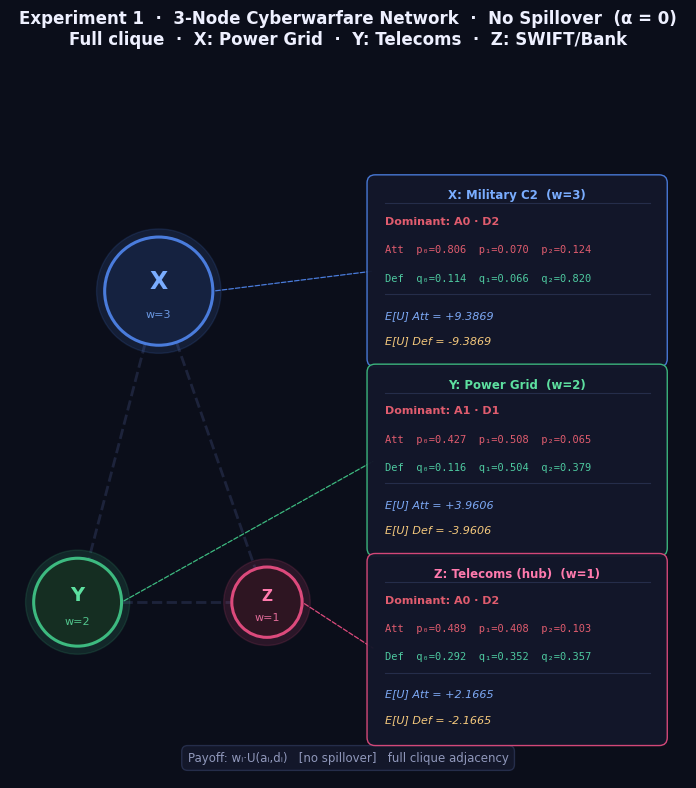

✓  exp1_3node_nospill_diagram.png


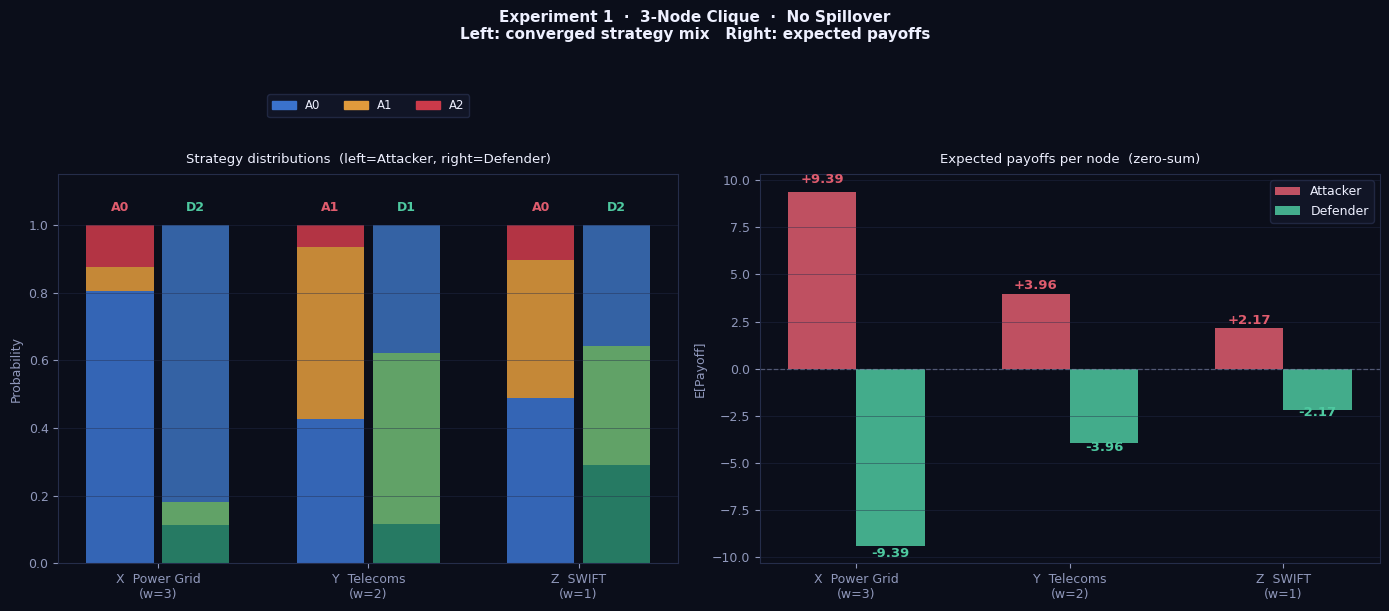

✓  exp1_3node_nospill_charts.png


In [2]:
"""
CELL 2 — EXPERIMENT 1: 3 Nodes, No Spillover (α = 0)
──────────────────────────────────────────────────────
Topology : full clique — every node connects to every other.
Nodes    : X = Military C2 (N0)  ·  Y = Power Grid (N1)  ·  Z = Telecoms (N2)
Weights  : X=3, Y=2, Z=1  (power-law ranking, top 3 nodes)
These are the top 3 nodes by intrinsic importance weight.
No spillover — establishes the baseline where weight alone drives payoffs.
"""
W3    = np.array([3., 2., 1.])
A3    = clique_adjacency(3)
SHORT3 = ['X', 'Y', 'Z']
LONG3  = ['Military C2', 'Power Grid', 'Telecoms']

r1 = run_experiment(3, alpha_att=0.0, alpha_def=0.0, adjacency=A3, weights=W3)

print('='*62)
print('  Experiment 1 — 3-node clique, no spillover (α = 0)')
print(f'  Adjacency:\n{A3}')
print('='*62)
for n, name in enumerate(SHORT3):
    p=r1['att_marg'][n]; q=r1['def_marg'][n]
    print(f'    Att mix : p0={p[0]:.3f}  p1={p[1]:.3f}  p2={p[2]:.3f}  {ACTION_NAMES[np.argmax(p)]}')
    print(f'    Def mix : q0={q[0]:.3f}  q1={q[1]:.3f}  q2={q[2]:.3f}  {DEFENSE_NAMES[np.argmax(q)]}')
    print(f'    E[U] att={r1["att_pay"][n]:+.4f}   E[U] def={r1["def_pay"][n]:+.4f}   sum={r1["att_pay"][n]+r1["def_pay"][n]:+.2e} ✓')

# ── Network diagram ────────────────────────────────────────────────────────────
NODE_XY3 = {'X':(0.22,0.72),'Y':(0.10,0.26),'Z':(0.38,0.26)}
NODE_R3  = {'X':0.080,'Y':0.065,'Z':0.052}
PANEL3   = {'X':(0.54,0.88),'Y':(0.54,0.60),'Z':(0.54,0.32)}
PW3,PH3  = 0.42, 0.26

fig,ax = plt.subplots(figsize=(13,8)); fig.patch.set_facecolor(BG)
ax.set_facecolor(BG); ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_aspect('equal'); ax.axis('off')
fig.suptitle('Experiment 1  ·  3-Node Cyberwarfare Network  ·  No Spillover  (α = 0)\n'
             'Full clique  ·  X: Military C2  ·  Y: Power Grid  ·  Z: Telecoms',
             fontsize=12, fontweight='bold', color=WHITE, y=0.99)

for (a,b) in [('X','Y'),('X','Z'),('Y','Z')]:
    x0,y0=NODE_XY3[a]; x1,y1=NODE_XY3[b]
    dx,dy=x1-x0,y1-y0; d_=np.sqrt(dx**2+dy**2); ux,uy=dx/d_,dy/d_
    Ra=NODE_R3[a]; Rb=NODE_R3[b]
    ax.plot([x0+ux*Ra,x1-ux*Rb],[y0+uy*Ra,y1-uy*Rb],
            color=BORDER,lw=2,linestyle='--',alpha=0.7,zorder=1)

for n,name in enumerate(SHORT3):
    x,y=NODE_XY3[name]; R=NODE_R3[name]; ci=n%len(NODE_RINGS)
    ax.add_patch(plt.Circle((x,y),R+0.012,color=NODE_RINGS[ci],alpha=0.15,zorder=2))
    ax.add_patch(plt.Circle((x,y),R,color=NODE_FILLS[ci],zorder=3))
    ax.add_patch(plt.Circle((x,y),R,fill=False,edgecolor=NODE_RINGS[ci],lw=2.2,zorder=4))
    ax.text(x,y+R*0.18,name,fontsize=[17,14,11][n],fontweight='bold',
            color=NODE_LBLS[ci],ha='center',va='center',zorder=5)
    ax.text(x,y-R*0.42,f'w={W3[n]:.0f}',fontsize=8,
            color=NODE_LBLS[ci],alpha=0.85,ha='center',va='center',zorder=5)

    px0,py1=PANEL3[name]; p_=r1['att_marg'][n]; q_=r1['def_marg'][n]
    da=ACTION_NAMES[np.argmax(p_)]; dd=DEFENSE_NAMES[np.argmax(q_)]
    ax.add_patch(mpatches.FancyBboxPatch((px0,py1-PH3),PW3,PH3,
        boxstyle='round,pad=0.012',facecolor=CARD,
        edgecolor=NODE_RINGS[ci],lw=1.0,zorder=6,alpha=0.96))
    tx=px0+0.014; row=py1-0.028; gap=PH3/6.2
    ax.text(px0+PW3/2,py1-0.008,f'{name}: {LONG3[n]}  (w={W3[n]:.0f})',
            fontsize=8.5,fontweight='bold',color=NODE_LBLS[ci],
            ha='center',va='top',zorder=7)
    ax.plot([px0+0.014,px0+PW3-0.014],[row-0.002]*2,color=BORDER,lw=0.8,zorder=7)
    row-=gap*0.5
    ax.text(tx,row,f'Dominant: {da} · {dd}',fontsize=8,fontweight='bold',
            color=ATT_COL,ha='left',va='top',zorder=7)
    row-=gap
    ax.text(tx,row,f'Att  p\u2080={p_[0]:.3f}  p\u2081={p_[1]:.3f}  p\u2082={p_[2]:.3f}',
            fontsize=7.5,color=ATT_COL,ha='left',va='top',zorder=7,fontfamily='monospace')
    row-=gap
    ax.text(tx,row,f'Def  q\u2080={q_[0]:.3f}  q\u2081={q_[1]:.3f}  q\u2082={q_[2]:.3f}',
            fontsize=7.5,color=DEF_COL,ha='left',va='top',zorder=7,fontfamily='monospace')
    row-=gap*0.75; ax.plot([px0+0.014,px0+PW3-0.014],[row]*2,color=BORDER,lw=0.8,zorder=7)
    row-=gap*0.55
    ax.text(tx,row,f'E[U] Att = {r1["att_pay"][n]:+.4f}',fontsize=8,color=PAY_A,
            fontstyle='italic',ha='left',va='top',zorder=7)
    row-=gap*0.9
    ax.text(tx,row,f'E[U] Def = {r1["def_pay"][n]:+.4f}',fontsize=8,color=PAY_D,
            fontstyle='italic',ha='left',va='top',zorder=7)
    pmid_y=py1-PH3/2
    ax.annotate('',xy=(px0,pmid_y),xytext=(x+NODE_R3[name],y),
                arrowprops=dict(arrowstyle='-',color=NODE_RINGS[ci],
                                lw=0.9,linestyle='dashed'),zorder=5)

ax.text(0.50,0.02,'Payoff: wᵢ·U(aᵢ,dᵢ)   [no spillover]   full clique adjacency',
        fontsize=8.5,color=MUTED,ha='center',va='bottom',
        bbox=dict(boxstyle='round,pad=0.5',facecolor=CARD,edgecolor=BORDER,lw=1.0))
plt.tight_layout(rect=[0,0.01,1,0.96])
plt.savefig('exp1_3node_nospill_diagram.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print('exp1_3node_nospill_diagram.png')

# ── Payoff bar chart ───────────────────────────────────────────────────────────
fig,axes=plt.subplots(1,2,figsize=(14,6)); fig.patch.set_facecolor(BG)
fig.suptitle('Experiment 1  ·  3-Node Clique  ·  No Spillover\n'
             'Left: converged strategy mix   Right: expected payoffs',
             fontsize=11,fontweight='bold',color=WHITE,y=1.01)

# strategy stacked bars
ax=axes[0]; style_ax(ax)
cols_a=['#3a72cc','#e09a3c','#cc3a4a']; cols_d=['#2a8a6e','#6eb872','#3a6eb8']
x3=np.arange(3); wd=0.32; bot_a=np.zeros(3); bot_d=np.zeros(3)
for s in range(3):
    va=r1['att_marg'][:,s]; vd=r1['def_marg'][:,s]
    ax.bar(x3-wd/2-0.02,va,wd,bottom=bot_a,color=cols_a[s],alpha=0.88,label=f'A{s}')
    ax.bar(x3+wd/2+0.02,vd,wd,bottom=bot_d,color=cols_d[s],alpha=0.88)
    bot_a+=va; bot_d+=vd
ax.set_xticks(x3)
ax.set_xticklabels(['X  Military C2\n(w=3)','Y  Power Grid\n(w=2)','Z  Telecoms\n(w=1)'],
                    color=MUTED,fontsize=9)
ax.set_ylim(0,1.15); ax.set_ylabel('Probability',color=MUTED,fontsize=9)
ax.set_title('Strategy distributions  (left=Attacker, right=Defender)',
             fontsize=9.5,color=WHITE,pad=8)
ax.grid(axis='y',color=BORDER,lw=0.6,alpha=0.5)
for n in range(3):
    ax.text(n-wd/2-0.02,1.04,ACTION_NAMES[np.argmax(r1['att_marg'][n])],
            ha='center',fontsize=9,color=ATT_COL,fontweight='bold')
    ax.text(n+wd/2+0.02,1.04,DEFENSE_NAMES[np.argmax(r1['def_marg'][n])],
            ha='center',fontsize=9,color=DEF_COL,fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=cols_a[s],label=f'A{s}') for s in range(3)],
          ncol=3,loc='upper center',bbox_to_anchor=(0.5,1.22),
          facecolor=CARD,edgecolor=BORDER,labelcolor=WHITE,fontsize=8.5)

# payoff bars
ax=axes[1]; style_ax(ax)
ba=ax.bar(x3-wd/2,r1['att_pay'],wd,color=ATT_COL,alpha=0.85,label='Attacker')
bd=ax.bar(x3+wd/2,r1['def_pay'],wd,color=DEF_COL,alpha=0.85,label='Defender')
ax.axhline(0,color=MUTED,lw=0.9,linestyle='--',alpha=0.5)
ax.set_xticks(x3)
ax.set_xticklabels(['X  Military C2\n(w=3)','Y  Power Grid\n(w=2)','Z  Telecoms\n(w=1)'],
                    color=MUTED,fontsize=9)
ax.set_title('Expected payoffs per node  (zero-sum)',fontsize=9.5,color=WHITE,pad=8)
ax.set_ylabel('E[Payoff]',color=MUTED,fontsize=9)
ax.grid(axis='y',color=BORDER,lw=0.6,alpha=0.5)
for bar,val in zip(ba,r1['att_pay']):
    ax.text(bar.get_x()+bar.get_width()/2,val+abs(val)*0.04+0.1,
            f'{val:+.2f}',ha='center',fontsize=9.5,color=ATT_COL,fontweight='bold')
for bar,val in zip(bd,r1['def_pay']):
    ax.text(bar.get_x()+bar.get_width()/2,val-abs(val)*0.04-0.25,
            f'{val:+.2f}',ha='center',fontsize=9.5,color=DEF_COL,fontweight='bold')
ax.legend(facecolor=CARD,edgecolor=BORDER,labelcolor=WHITE,fontsize=9)

plt.tight_layout()
plt.savefig('exp1_3node_nospill_charts.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print('exp1_3node_nospill_charts.png')


Experiment 2 — 5-node hub-and-spoke, no spillover (α = 0)
Weights (β=0.7): [np.float64(1.797), np.float64(1.106), np.float64(0.833), np.float64(0.681), np.float64(0.583)]
Strategy space : 3^5 = 243 joint profiles
Adjacency (N2=hub):
[[0 1 1 0 0]
 [1 0 1 1 0]
 [1 1 0 1 1]
 [0 1 1 0 0]
 [0 0 1 0 0]]

  N0 Military C2            w=1.797  nb=['N1', 'N2']
     [SolarWinds 2020]
     att=A0  def=D2  E[U]_A=+5.567

  N1 Power Grid             w=1.106  nb=['N0', 'N2', 'N3']
     [Ukraine 2015/16]
     att=A1  def=D1  E[U]_A=+2.060

  N2 Telecoms (hub)         w=0.833  nb=['N0', 'N1', 'N3', 'N4']
     [Viasat 2022]
     att=A0  def=D2  E[U]_A=+1.804

  N3 SWIFT/Bank             w=0.681  nb=['N1', 'N2']
     [Bangladesh Bank 2016]
     att=A2  def=D2  E[U]_A=-1.836

  N4 Nuclear/SCADA          w=0.583  nb=['N2']
     [Stuxnet 2010]
     att=A0  def=D2  E[U]_A=+1.876



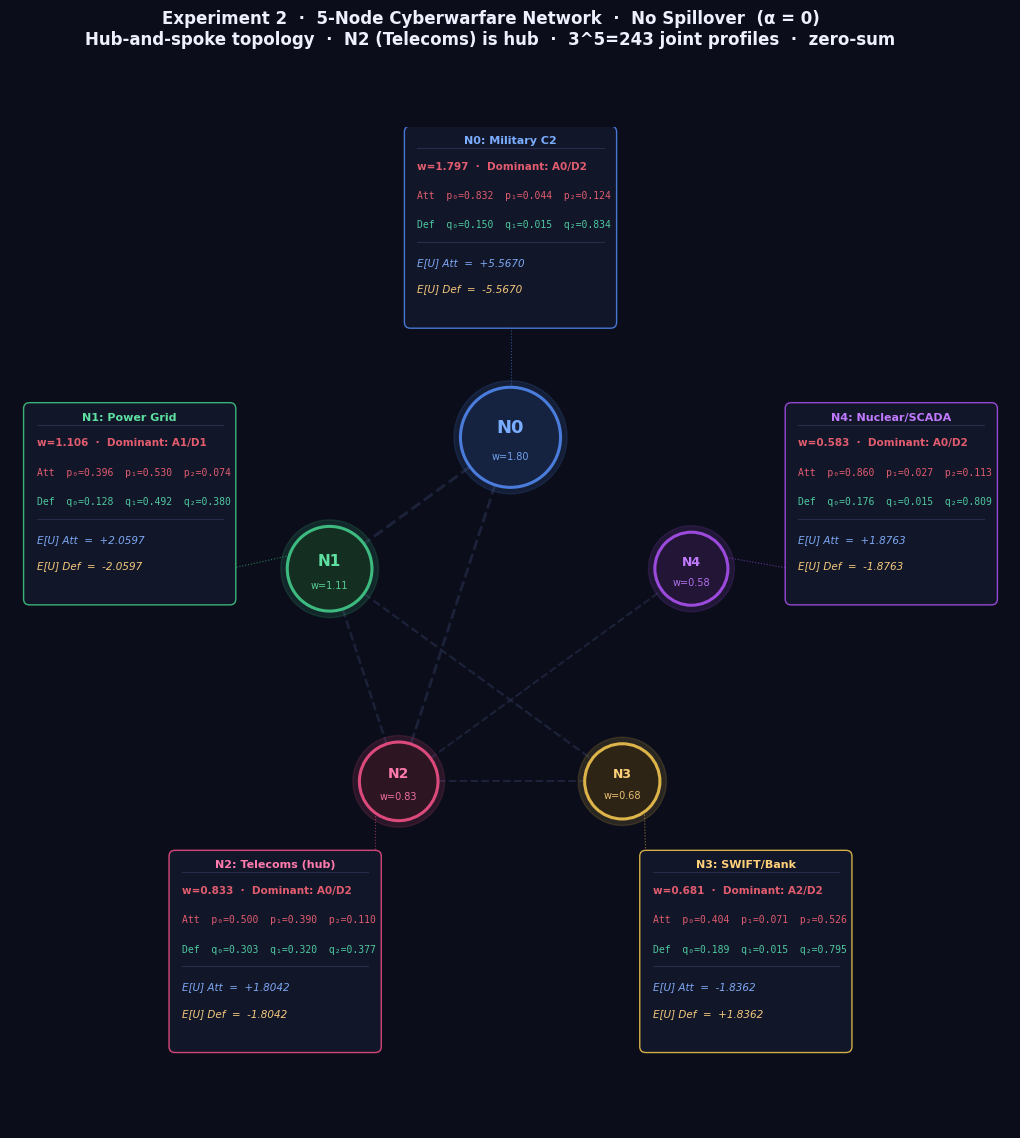

✓  exp2_5n_hub_nospill_network.png  →  run Cell 3b for charts


In [3]:
"""
CELL 3 — EXPERIMENT 2: 5-Node Hub-and-Spoke Baseline, No Spillover
─────────────────────────────────────────────────────────────────────────
This experiment fixes the 5-node hub-and-spoke topology used in the thesis.
Telecoms (N2) acts as the hub, while Power Grid (N1) remains highly connected.
The output is used by Cell 3b for the payoff and strategy charts.
"""
n_nodes = 5   # five-node network used in the thesis experiment

shorts, longs = node_labels(n_nodes)[:2]
A_hub = hub_adjacency(n_nodes)
W_n   = power_law_weights(n_nodes)

r2 = run_experiment(n_nodes, alpha_att=0.0, alpha_def=0.0,
                    adjacency=A_hub, weights=W_n)
w   = r2['weights']
adj = r2['adjacency']

print(f'Experiment 2 — {n_nodes}-node hub-and-spoke, no spillover (α = 0)')
print(f'Weights (β=0.7): {[round(x,3) for x in w]}')
print(f'Strategy space : 3^{n_nodes} = {3**n_nodes} joint profiles')
print(f'Adjacency (N2=hub):\n{adj}\n')
for i in range(n_nodes):
    p_=r2['att_marg'][i]; q_=r2['def_marg'][i]
    nbs=[shorts[j] for j in range(n_nodes) if adj[i,j]]
    print(f'  {shorts[i]} {longs[i]:<22} w={w[i]:.3f}  nb={nbs}')
    print(f'     att={ACTION_NAMES[np.argmax(p_)]}  def={DEFENSE_NAMES[np.argmax(q_)]}  '
          f'E[U]_A={r2["att_pay"][i]:+.3f}')
    print()

# Network diagram (uses shared draw_network_figure)
fig = draw_network_figure(
    r2,
    title=f'Experiment 2  ·  {n_nodes}-Node Cyberwarfare Network  ·  No Spillover  (α = 0)',
    subtitle=f'Hub-and-spoke topology  ·  N2 (Telecoms) is hub  ·  '
             f'3^{n_nodes}={3**n_nodes} joint profiles  ·  zero-sum',
    node_short=shorts, node_long=longs)

plt.savefig(f'exp2_{n_nodes}n_hub_nospill_network.png',
            dpi=150,bbox_inches='tight',facecolor=BG)
plt.show()
print(f'exp2_{n_nodes}n_hub_nospill_network.png   run Cell 3b for charts')


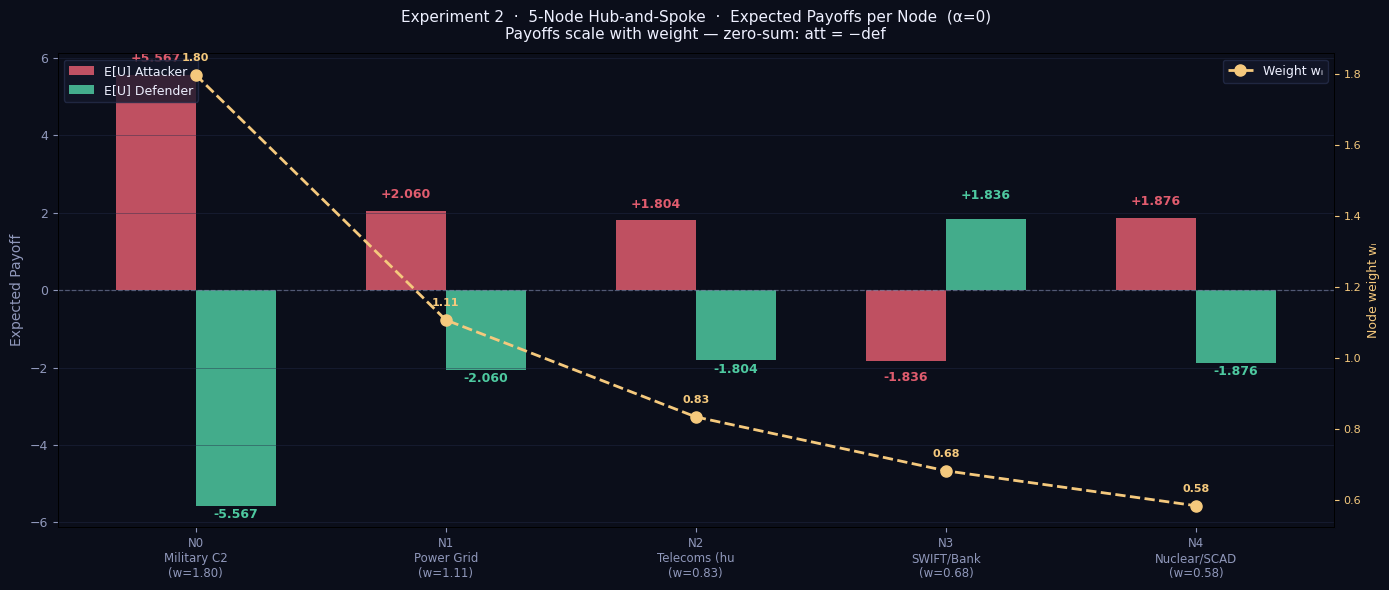

✓  exp2_5n_hub_nospill_payoffs.png


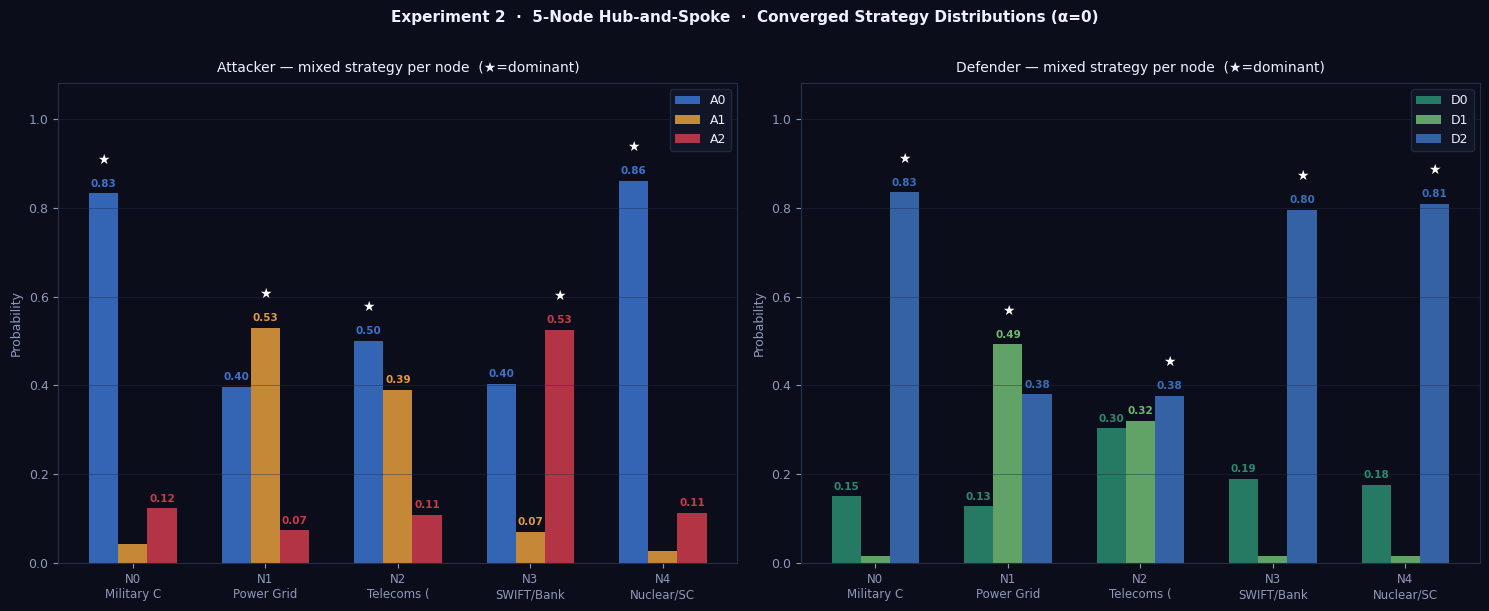

✓  exp2_5n_hub_nospill_strategies.png


In [4]:
"""
CELL 3b — EXPERIMENT 2: Charts  (reads r2, w, shorts, longs from Cell 3)
"""
x_idx = np.arange(n_nodes); wd = 0.32

# Figure 1: expected payoffs + weight overlay
fig,ax_pay = plt.subplots(figsize=(max(10,2*n_nodes+4),6))
fig.patch.set_facecolor(BG); style_ax(ax_pay)
ba=ax_pay.bar(x_idx-wd/2,r2['att_pay'],wd,color=ATT_COL,alpha=0.85,label='E[U] Attacker')
bd=ax_pay.bar(x_idx+wd/2,r2['def_pay'],wd,color=DEF_COL,alpha=0.85,label='E[U] Defender')
ax_pay.axhline(0,color=MUTED,lw=0.9,linestyle='--',alpha=0.5)
ax_pay.set_xticks(x_idx)
ax_pay.set_xticklabels([f'{shorts[i]}\n{longs[i][:12]}\n(w={w[i]:.2f})'
                         for i in range(n_nodes)],color=MUTED,fontsize=8.5)
ax_pay.set_title(f'Experiment 2  ·  {n_nodes}-Node Hub-and-Spoke  ·  '
                 f'Expected Payoffs per Node  (α=0)\n'
                 f'Payoffs scale with weight — zero-sum: att = −def',
                 fontsize=11,color=WHITE,pad=10)
ax_pay.set_ylabel('Expected Payoff',color=MUTED,fontsize=10)
ax_pay.grid(axis='y',color=BORDER,lw=0.6,alpha=0.5)
y_rng=max(abs(v) for v in list(r2['att_pay'])+list(r2['def_pay'])) or 1
off=y_rng*0.04+0.1
for bar,val in zip(ba,r2['att_pay']):
    ax_pay.text(bar.get_x()+bar.get_width()/2,val+(off if val>=0 else -off*1.6),
                f'{val:+.3f}',ha='center',fontsize=9,color=ATT_COL,fontweight='bold')
for bar,val in zip(bd,r2['def_pay']):
    ax_pay.text(bar.get_x()+bar.get_width()/2,val-(off if val<=0 else -off*1.6),
                f'{val:+.3f}',ha='center',fontsize=9,color=DEF_COL,fontweight='bold')
ax_w=ax_pay.twinx(); ax_w.set_facecolor(BG)
ax_w.plot(x_idx,w,'o--',color=PAY_D,lw=2,markersize=8,label='Weight wᵢ')
for i,wi in enumerate(w):
    ax_w.text(i,wi+0.04,f'{wi:.2f}',ha='center',fontsize=8,color=PAY_D,fontweight='bold')
ax_w.set_ylabel('Node weight wᵢ',color=PAY_D,fontsize=9)
ax_w.tick_params(axis='y',colors=PAY_D,labelsize=8)
ax_pay.legend(facecolor=CARD,edgecolor=BORDER,labelcolor=WHITE,fontsize=9,loc='upper left')
ax_w.legend(facecolor=CARD,edgecolor=BORDER,labelcolor=WHITE,fontsize=9,loc='upper right')
plt.tight_layout()
plt.savefig(f'exp2_{n_nodes}n_hub_nospill_payoffs.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print(f'exp2_{n_nodes}n_hub_nospill_payoffs.png')

# Figure 2: strategy distributions — attacker and defender side by side
fig,axes=plt.subplots(1,2,figsize=(max(14,3*n_nodes),6)); fig.patch.set_facecolor(BG)
fig.suptitle(f'Experiment 2  ·  {n_nodes}-Node Hub-and-Spoke  ·  '
             f'Converged Strategy Distributions (α=0)',
             fontsize=11,fontweight='bold',color=WHITE,y=1.01)
action_cols=['#3a72cc','#e09a3c','#cc3a4a']
defense_cols=['#2a8a6e','#6eb872','#3a6eb8']
bar_w=0.22; offsets=np.array([-bar_w,0,bar_w])
for ax_idx,(cols,marg,player,names) in enumerate([
        (action_cols,r2['att_marg'],'Attacker',ACTION_NAMES),
        (defense_cols,r2['def_marg'],'Defender',DEFENSE_NAMES)]):
    ax=axes[ax_idx]; style_ax(ax)
    for s in range(3):
        bars=ax.bar(x_idx+offsets[s],marg[:,s],bar_w,
                    color=cols[s],alpha=0.88,label=names[s])
        for bar,val in zip(bars,marg[:,s]):
            if val>0.05:
                ax.text(bar.get_x()+bar.get_width()/2,val+0.015,
                        f'{val:.2f}',ha='center',fontsize=7.5,
                        color=cols[s],fontweight='bold')
    for i in range(n_nodes):
        dom=np.argmax(marg[i])
        ax.annotate('★',xy=(i+offsets[dom],marg[i,dom]+0.06),
                    fontsize=10,color='white',ha='center',va='bottom')
    ax.set_ylim(0,1.08); ax.set_xticks(x_idx)
    ax.set_xticklabels([f'{shorts[i]}\n{longs[i][:10]}'
                         for i in range(n_nodes)],color=MUTED,fontsize=8.5)
    ax.set_ylabel('Probability',color=MUTED,fontsize=9)
    ax.set_title(f'{player} — mixed strategy per node  (★=dominant)',
                 fontsize=10,color=WHITE,pad=8)
    ax.grid(axis='y',color=BORDER,lw=0.6,alpha=0.5)
    ax.legend(facecolor=CARD,edgecolor=BORDER,labelcolor=WHITE,fontsize=9,loc='upper right')
plt.tight_layout()
plt.savefig(f'exp2_{n_nodes}n_hub_nospill_strategies.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show(); print(f'exp2_{n_nodes}n_hub_nospill_strategies.png')


✓  No Spillover  (α = 0)
✓  Full Spillover  (α = 0.35)

Case                      Node   Dom A/D   E[U] Att  E[U] Def
──────────────────────────────────────────────────────────
No Spillover  (α = 0)     X       A0/D2       9.387    -9.387
                          Y       A1/D1       3.961    -3.961
                          Z       A0/D2       2.167    -2.167
Full Spillover  (α = 0.35) X       A0/D2      11.735   -11.735
                          Y       A1/D2      13.321   -13.321
                          Z       A0/D2      11.208   -11.208


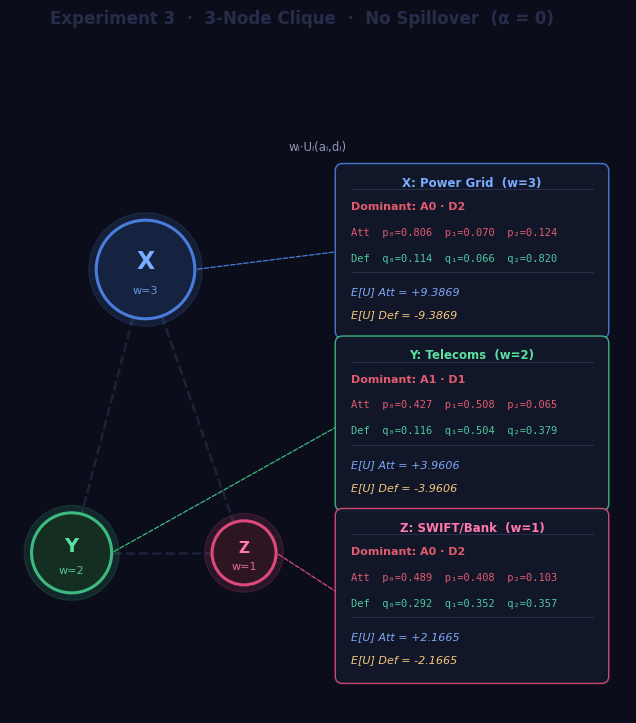

✓  exp3_3n_clique_nospill.png


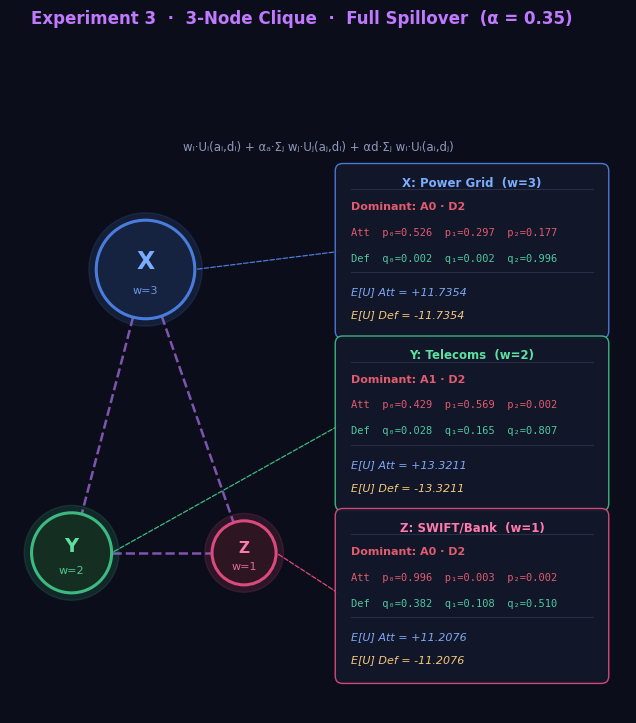

✓  exp3_3n_clique_fullspill.png

→ Run Cell 4b for payoff comparison chart


In [5]:
"""
CELL 4a — EXPERIMENT 3: 3 Nodes, Clique  ·  No Spillover vs Full Spillover
────────────────────────────────────────────────────────────────────────────
Same 3-node full clique as Experiment 1.
Two conditions only: no spillover (baseline) and full spillover (α=0.35).
The comparison isolates the pure effect of network propagation on payoffs
and strategy, holding topology, weights, and node matrices constant.
results3 carries through to Cell 4b.
"""
ALPHA  = 0.35
W3     = np.array([3., 2., 1.])
A3     = clique_adjacency(3)
SHORT3 = ['X', 'Y', 'Z']
LONG3  = ['Military C2', 'Power Grid', 'Telecoms']

CASES3 = [
    ('No Spillover  (α = 0)',      0.0,   0.0,   BORDER,  'wᵢ·Uᵢ(aᵢ,dᵢ)'),
    ('Full Spillover  (α = 0.35)', ALPHA, ALPHA, '#c07aff',
     'wᵢ·Uᵢ(aᵢ,dᵢ) + αₐ·Σⱼ wⱼ·Uⱼ(aⱼ,dᵢ) + αd·Σⱼ wᵢ·Uᵢ(aᵢ,dⱼ)'),
]

results3 = []
for label, aa, ad, col, _ in CASES3:
    r = run_experiment(3, alpha_att=aa, alpha_def=ad, adjacency=A3, weights=W3)
    results3.append(r)
    print(f'{label}')

# Print comparison table
print(f'\n{"Case":<25} {"Node":<5} {"Dom A/D":^9} {"E[U] Att":>9} {"E[U] Def":>9}')
print('─'*58)
for (lbl,_,_,_,_), r in zip(CASES3, results3):
    for n, name in enumerate(SHORT3):
        da = ACTION_NAMES[np.argmax(r['att_marg'][n])]
        dd = DEFENSE_NAMES[np.argmax(r['def_marg'][n])]
        print(f'{lbl if n==0 else "":<25} {name:<5} {da+"/"+dd:^9} '
              f'{r["att_pay"][n]:>9.3f} {r["def_pay"][n]:>9.3f}')

# Node positions and layout (same as before)
NODE_XY3 = {'X':(0.22,0.72), 'Y':(0.10,0.26), 'Z':(0.38,0.26)}
NODE_R3  = {'X':0.080, 'Y':0.065, 'Z':0.052}
PANEL3   = {'X':(0.54,0.88), 'Y':(0.54,0.60), 'Z':(0.54,0.32)}
PW3, PH3 = 0.42, 0.26

for idx, (label, aa, ad, ecol, formula) in enumerate(CASES3):
    r = results3[idx]
    fig, ax = plt.subplots(figsize=(13, 8))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG); ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_aspect('equal'); ax.axis('off')
    fig.suptitle(f'Experiment 3  ·  3-Node Clique  ·  {label}',
                 fontsize=12, fontweight='bold', color=ecol, y=0.99)
    ax.text(0.50, 0.93, formula, fontsize=8.5, color=MUTED,
            ha='center', va='top')

    for (a, b) in [('X','Y'),('X','Z'),('Y','Z')]:
        x0,y0=NODE_XY3[a]; x1,y1=NODE_XY3[b]
        dx,dy=x1-x0,y1-y0; d_=np.sqrt(dx**2+dy**2); ux,uy=dx/d_,dy/d_
        ax.plot([x0+ux*NODE_R3[a], x1-ux*NODE_R3[b]],
                [y0+uy*NODE_R3[a], y1-uy*NODE_R3[b]],
                color=ecol, lw=1.8, linestyle='--', alpha=0.65, zorder=1)

    for n, name in enumerate(SHORT3):
        x,y=NODE_XY3[name]; R=NODE_R3[name]; ci=n%len(NODE_RINGS)
        ax.add_patch(plt.Circle((x,y),R+0.012,color=NODE_RINGS[ci],alpha=0.15,zorder=2))
        ax.add_patch(plt.Circle((x,y),R,color=NODE_FILLS[ci],zorder=3))
        ax.add_patch(plt.Circle((x,y),R,fill=False,edgecolor=NODE_RINGS[ci],lw=2.2,zorder=4))
        ax.text(x,y+R*0.18,name,fontsize=[17,14,11][n],fontweight='bold',
                color=NODE_LBLS[ci],ha='center',va='center',zorder=5)
        ax.text(x,y-R*0.42,f'w={W3[n]:.0f}',fontsize=8,
                color=NODE_LBLS[ci],alpha=0.85,ha='center',va='center',zorder=5)

        px0,py1=PANEL3[name]; p_=r['att_marg'][n]; q_=r['def_marg'][n]
        da=ACTION_NAMES[np.argmax(p_)]; dd=DEFENSE_NAMES[np.argmax(q_)]
        ax.add_patch(mpatches.FancyBboxPatch((px0,py1-PH3),PW3,PH3,
            boxstyle='round,pad=0.012',facecolor=CARD,
            edgecolor=NODE_RINGS[ci],lw=1.0,zorder=6,alpha=0.96))
        tx=px0+0.014; row=py1-0.028; gap=PH3/6.2
        ax.text(px0+PW3/2,py1-0.008,f'{name}: {LONG3[n]}  (w={W3[n]:.0f})',
                fontsize=8.5,fontweight='bold',color=NODE_LBLS[ci],
                ha='center',va='top',zorder=7)
        ax.plot([px0+0.014,px0+PW3-0.014],[row-0.002]*2,color=BORDER,lw=0.8,zorder=7)
        row -= gap*0.5
        ax.text(tx,row,f'Dominant: {da} · {dd}',fontsize=8,fontweight='bold',
                color=ATT_COL,ha='left',va='top',zorder=7)
        row -= gap
        ax.text(tx,row,f'Att  p\u2080={p_[0]:.3f}  p\u2081={p_[1]:.3f}  p\u2082={p_[2]:.3f}',
                fontsize=7.5,color=ATT_COL,ha='left',va='top',zorder=7,fontfamily='monospace')
        row -= gap
        ax.text(tx,row,f'Def  q\u2080={q_[0]:.3f}  q\u2081={q_[1]:.3f}  q\u2082={q_[2]:.3f}',
                fontsize=7.5,color=DEF_COL,ha='left',va='top',zorder=7,fontfamily='monospace')
        row -= gap*0.75
        ax.plot([px0+0.014,px0+PW3-0.014],[row]*2,color=BORDER,lw=0.8,zorder=7)
        row -= gap*0.55
        ax.text(tx,row,f'E[U] Att = {r["att_pay"][n]:+.4f}',fontsize=8,color=PAY_A,
                fontstyle='italic',ha='left',va='top',zorder=7)
        row -= gap*0.9
        ax.text(tx,row,f'E[U] Def = {r["def_pay"][n]:+.4f}',fontsize=8,color=PAY_D,
                fontstyle='italic',ha='left',va='top',zorder=7)
        ax.annotate('',xy=(px0,py1-PH3/2),xytext=(x+NODE_R3[name],y),
                    arrowprops=dict(arrowstyle='-',color=NODE_RINGS[ci],
                                    lw=0.9,linestyle='dashed'),zorder=5)

    fname = f'exp3_3n_clique_{"nospill" if aa==0 else "fullspill"}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show(); print(f'{fname}')
print('\nRun Cell 4b for payoff comparison chart')


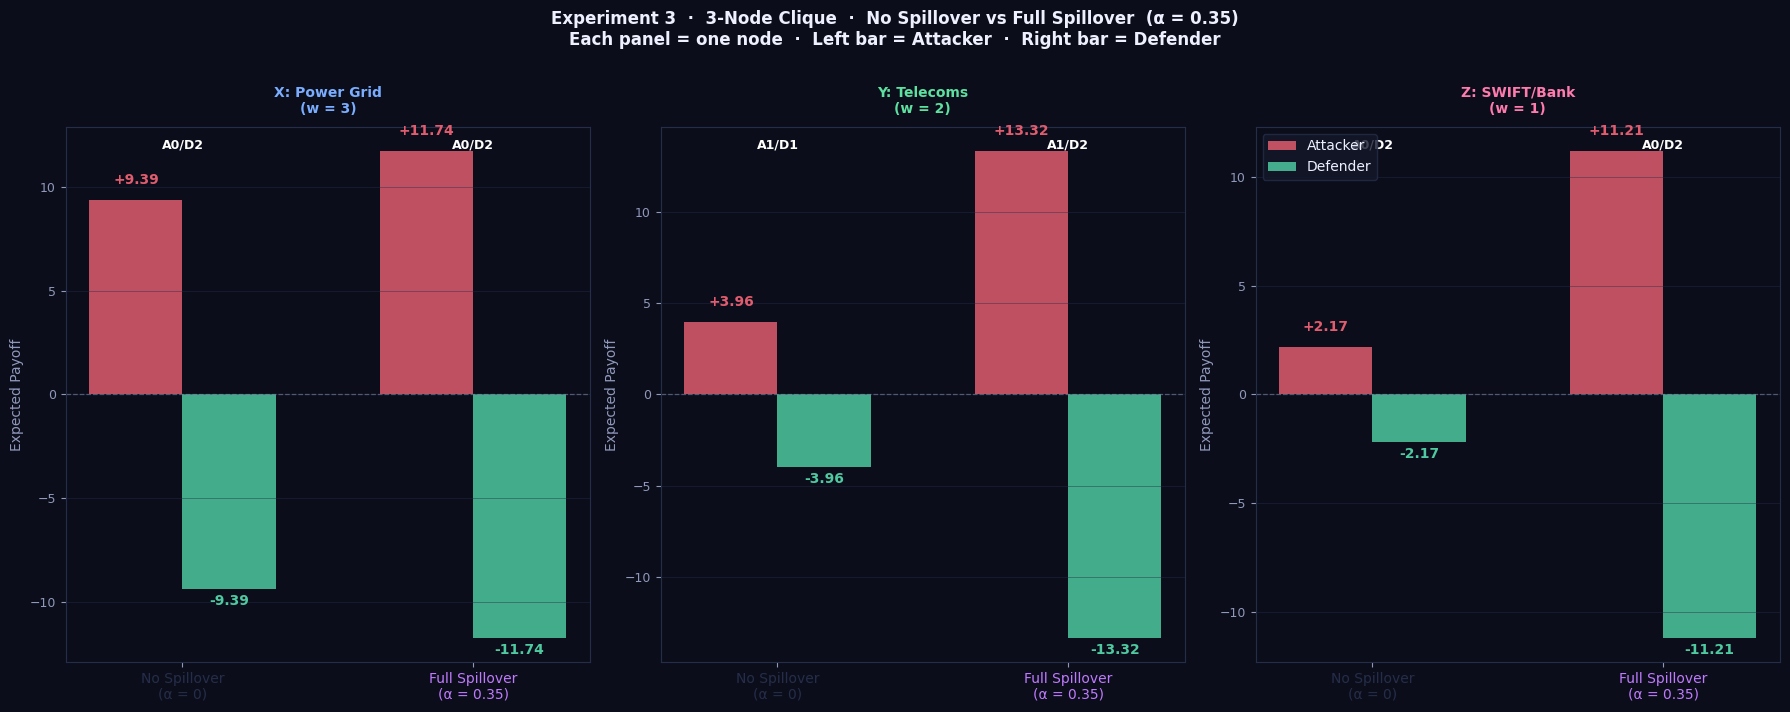

✓  exp3_3n_clique_comparison.png


In [6]:
"""
CELL 4b — EXPERIMENT 3: 3-Node Clique  ·  Payoff Comparison Chart
──────────────────────────────────────────────────────────────────
Two-panel figure: no spillover vs full spillover side by side.
Shows how full spillover amplifies payoffs at each node relative to baseline.
"""
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)
fig.patch.set_facecolor(BG)
fig.suptitle(
    'Experiment 3  ·  3-Node Clique  ·  No Spillover vs Full Spillover  (α = 0.35)\n'
    'Each panel = one node  ·  Left bar = Attacker  ·  Right bar = Defender',
    fontsize=12, fontweight='bold', color=WHITE, y=1.01)

CASE_LABELS = ['No Spillover\n(α = 0)', 'Full Spillover\n(α = 0.35)']
CASE_COLS   = [BORDER, '#c07aff']
x_idx = np.arange(2); wd = 0.32

for col_idx, name in enumerate(SHORT3):
    ax = axes[col_idx]; style_ax(ax)
    ci = col_idx % len(NODE_RINGS)

    att_vals = [r['att_pay'][col_idx] for r in results3]
    def_vals = [r['def_pay'][col_idx] for r in results3]

    b_a = ax.bar(x_idx-wd/2, att_vals, wd, color=ATT_COL, alpha=0.85, label='Attacker')
    b_d = ax.bar(x_idx+wd/2, def_vals, wd, color=DEF_COL, alpha=0.85, label='Defender')
    ax.axhline(0, color=MUTED, lw=0.9, linestyle='--', alpha=0.5)

    ax.set_xticks(x_idx)
    ax.set_xticklabels(CASE_LABELS, color=MUTED, fontsize=10)
    for tick, col in zip(ax.get_xticklabels(), CASE_COLS):
        tick.set_color(col)

    ax.set_title(f'{name}: {LONG3[col_idx]}\n(w = {W3[col_idx]:.0f})',
                 fontsize=10, fontweight='bold',
                 color=NODE_LBLS[col_idx % len(NODE_LBLS)], pad=10)
    ax.set_ylabel('Expected Payoff', color=MUTED, fontsize=10)
    ax.grid(axis='y', color=BORDER, lw=0.6, alpha=0.5)

    # Dominant action annotations above bars
    for i, r in enumerate(results3):
        da = ACTION_NAMES[np.argmax(r['att_marg'][col_idx])]
        dd = DEFENSE_NAMES[np.argmax(r['def_marg'][col_idx])]
        ax.text(i, ax.get_ylim()[1]*0.92 if ax.get_ylim()[1]>0 else 1,
                f'{da}/{dd}', ha='center', fontsize=9,
                color='white', fontweight='bold')

    y_rng = max(abs(v) for v in att_vals+def_vals) or 1
    off = y_rng*0.05+0.2
    for bar,val in zip(b_a, att_vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                val+(off if val>=0 else -off*1.5),
                f'{val:+.2f}', ha='center', fontsize=10,
                color=ATT_COL, fontweight='bold')
    for bar,val in zip(b_d, def_vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                val-(off if val<=0 else -off*1.5),
                f'{val:+.2f}', ha='center', fontsize=10,
                color=DEF_COL, fontweight='bold')

    if col_idx == 2:
        ax.legend(facecolor=CARD, edgecolor=BORDER, labelcolor=WHITE,
                  fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('exp3_3n_clique_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('exp3_3n_clique_comparison.png')


✓  No Spillover  (α = 0)
✓  Full Spillover  (α = 0.35)

Case                      Node                       Dom A/D   E[U] Att  E[U] Def
───────────────────────────────────────────────────────────────────────────
No Spillover  (α = 0)     N0 Military C2              A0/D2       5.567    -5.567
                          N1 Power Grid               A1/D1       2.060    -2.060
                          N2 Telecoms (hub)           A0/D2       1.804    -1.804
                          N3 SWIFT/Bank               A2/D2      -1.836     1.836
                          N4 Nuclear/SCADA            A0/D2       1.876    -1.876

Full Spillover  (α = 0.35) N0 Military C2              A0/D2       9.209    -9.209
                          N1 Power Grid               A1/D2       6.748    -6.748
                          N2 Telecoms (hub)           A0/D2       9.424    -9.424
                          N3 SWIFT/Bank               A2/D0      -2.235     2.235
                          N4 Nuclear/SCADA    

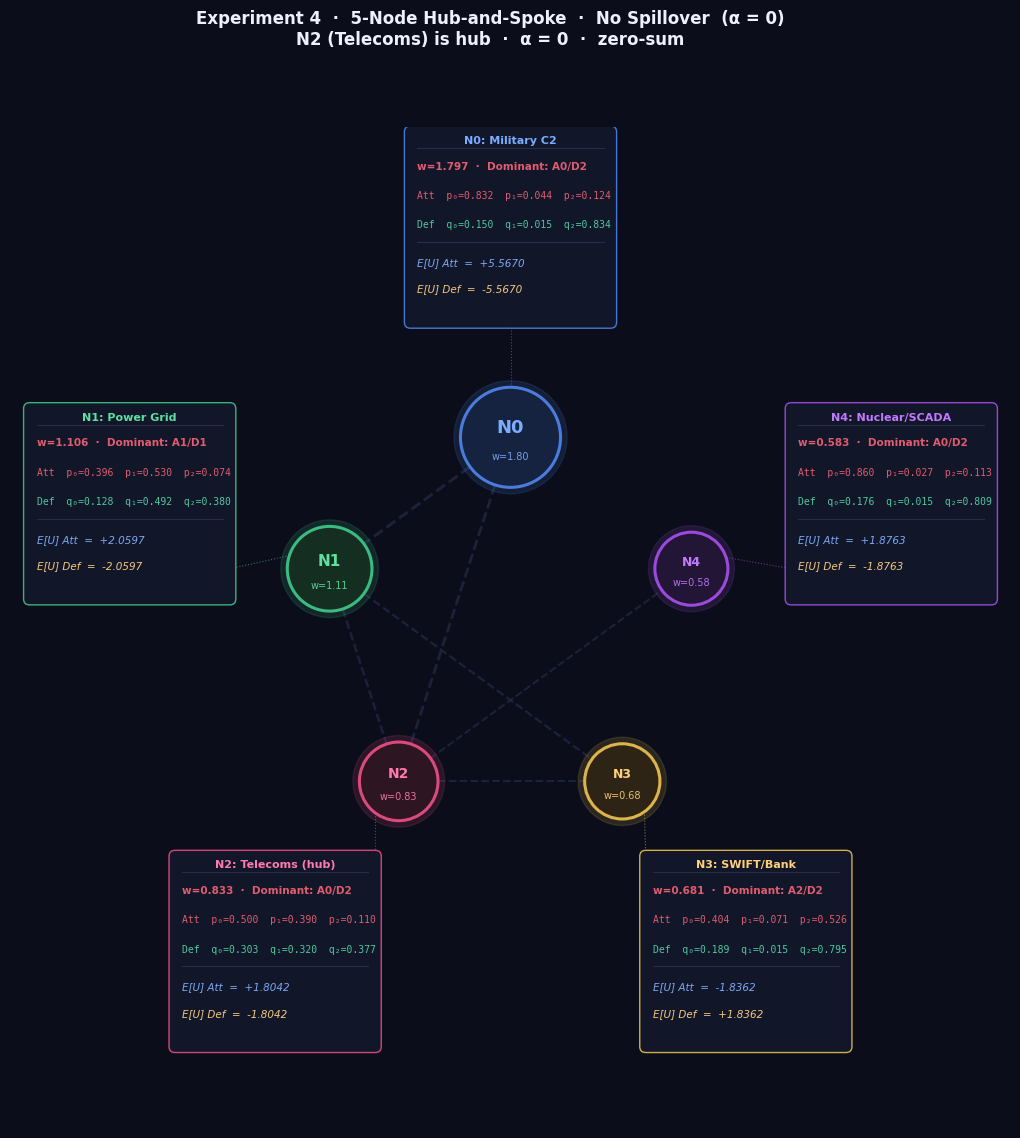

✓  exp4_5n_hub_nospill.png


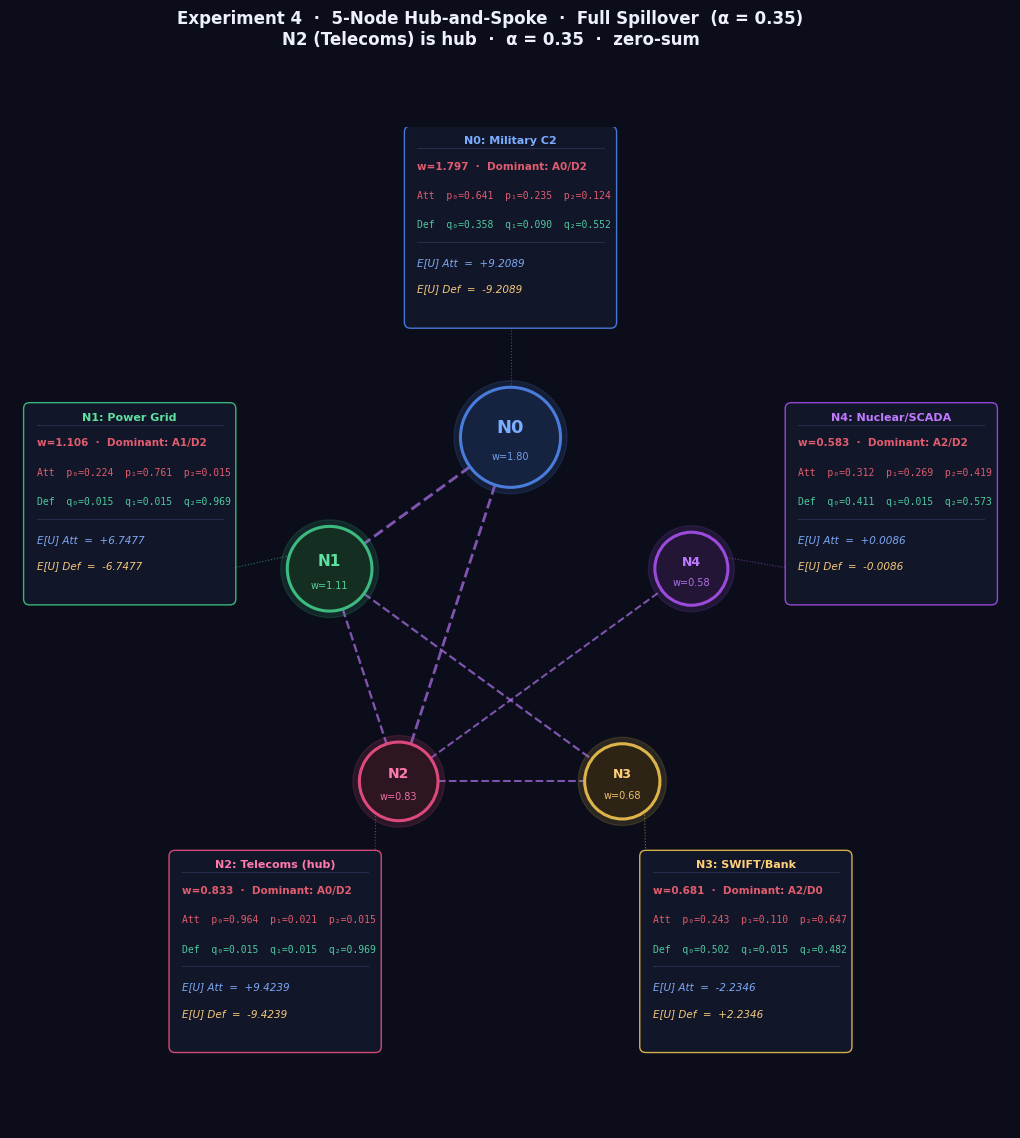

✓  exp4_5n_hub_fullspill.png

→ Run Cell 5b for payoff comparison + hub centrality convergence


In [7]:
"""
CELL 5a — EXPERIMENT 4: 5-Node Hub-and-Spoke  ·  No Spillover vs Full Spillover
────────────────────────────────────────────────────────────────────────────────
Two conditions: no spillover and full spillover (α=0.35).
One network diagram per condition.  results_n5 carries to Cell 5b.
"""
ALPHA = 0.35
shorts5, longs5 = node_labels(5)
A5  = hub_adjacency(5)
w5  = power_law_weights(5)

CASES5 = [
    ('No Spillover  (α = 0)',      0.0,   0.0,   BORDER),
    ('Full Spillover  (α = 0.35)', ALPHA, ALPHA, '#c07aff'),
]

results_n5 = []
for label, aa, ad, col in CASES5:
    r = run_experiment(5, alpha_att=aa, alpha_def=ad, adjacency=A5, weights=w5)
    results_n5.append(r)
    print(f'{label}')

# Print comparison table
print(f'\n{"Case":<25} {"Node":<25} {"Dom A/D":^9} {"E[U] Att":>9} {"E[U] Def":>9}')
print('─'*75)
for (lbl,_,_,_), r in zip(CASES5, results_n5):
    for i in range(5):
        da = ACTION_NAMES[np.argmax(r['att_marg'][i])]
        dd = DEFENSE_NAMES[np.argmax(r['def_marg'][i])]
        node_str = f'{shorts5[i]} {longs5[i][:18]}'
        print(f'{lbl if i==0 else "":<25} {node_str:<25} {da+"/"+dd:^9} '
              f'{r["att_pay"][i]:>9.3f} {r["def_pay"][i]:>9.3f}')
    print()

# One network diagram per condition
for idx, (label, aa, ad, ecol) in enumerate(CASES5):
    fig = draw_network_figure(
        results_n5[idx],
        title=f'Experiment 4  ·  5-Node Hub-and-Spoke  ·  {label}',
        subtitle=f'N2 (Telecoms) is hub  ·  α = {ALPHA if aa>0 else 0}  ·  zero-sum',
        edge_color=ecol,
        node_short=shorts5, node_long=longs5)
    fname = f'exp4_5n_hub_{"nospill" if aa==0 else "fullspill"}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show(); print(f'{fname}')

print('\nRun Cell 5b for payoff comparison and hub centrality convergence')


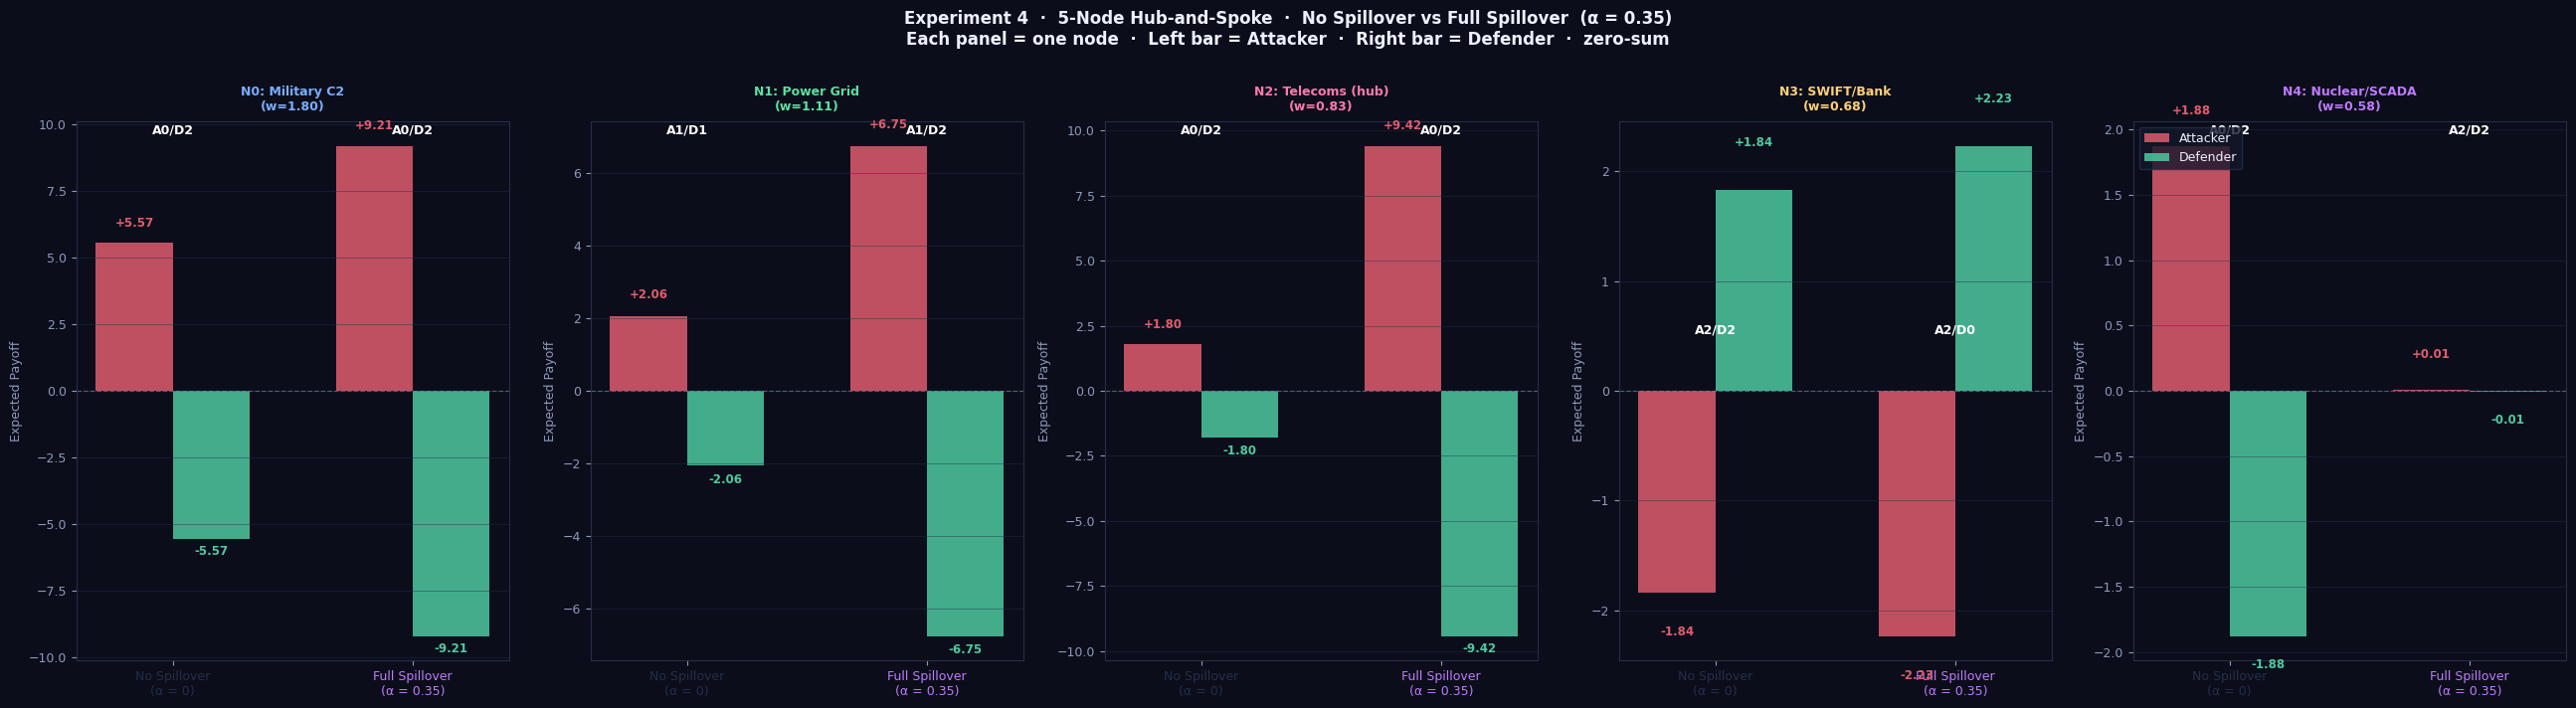

✓  exp4_5n_hub_payoff_comparison.png

Computing hub centrality convergence...
  n=3: weight_share=0.223  E[U]_share(spill)=0.400  hub_premium=+0.177
  n=4: weight_share=0.189  E[U]_share(spill)=0.407  hub_premium=+0.219
  n=5: weight_share=0.167  E[U]_share(spill)=0.407  hub_premium=+0.240
  n=6: weight_share=0.151  E[U]_share(spill)=0.431  hub_premium=+0.280


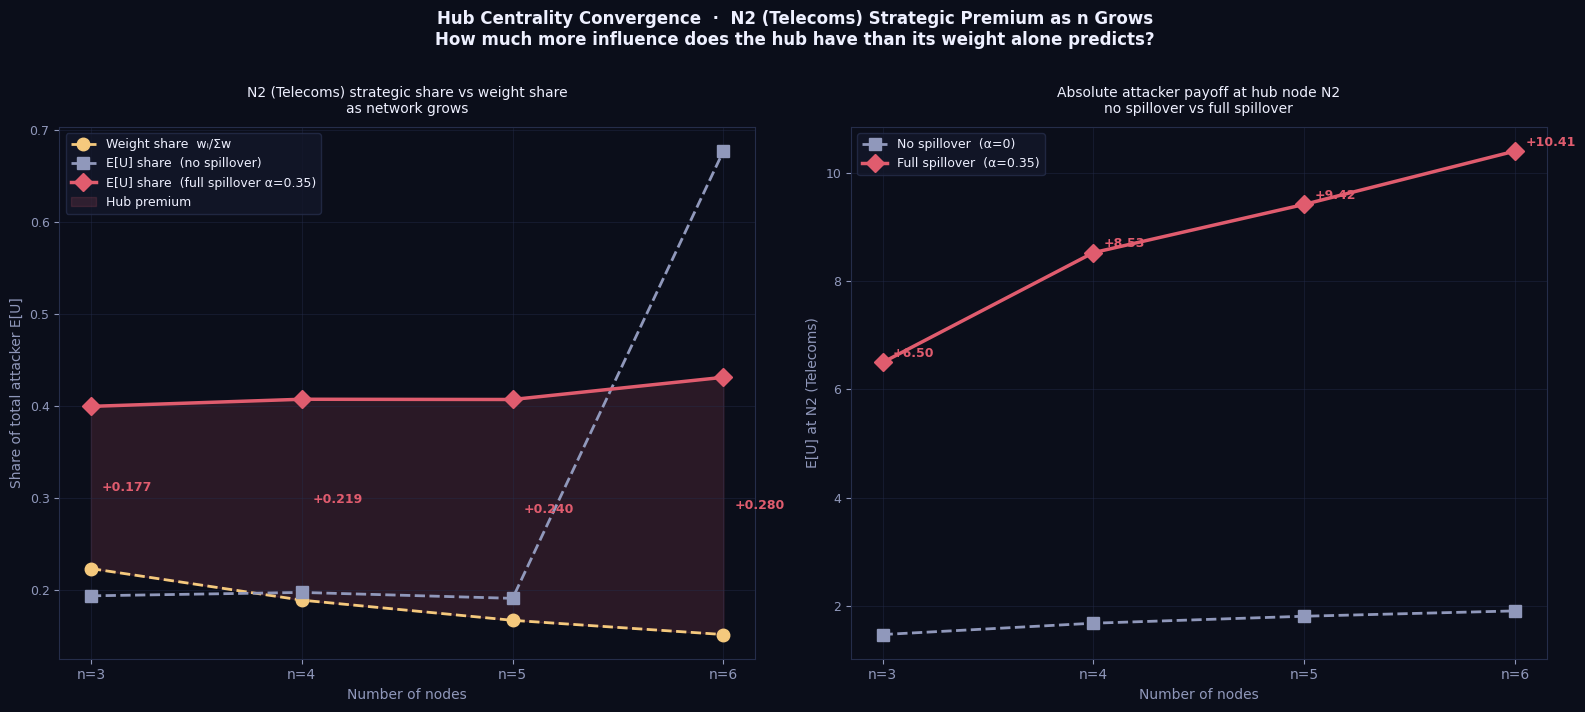

✓  exp4_hub_centrality_convergence.png


In [8]:
"""
CELL 5b — EXPERIMENT 4: Payoff Comparison + Hub Centrality Convergence
────────────────────────────────────────────────────────────────────────
Figure 1: No spillover vs full spillover payoffs per node (5-node hub).
Figure 2: Hub centrality convergence — N2's strategic premium as n grows.
"""

# ── Figure 1: payoff comparison, no spill vs full spill ───────────────────────
fig, axes = plt.subplots(1, 5, figsize=(26, 7), sharey=False)
fig.patch.set_facecolor(BG)
fig.suptitle(
    'Experiment 4  ·  5-Node Hub-and-Spoke  ·  No Spillover vs Full Spillover  (α = 0.35)\n'
    'Each panel = one node  ·  Left bar = Attacker  ·  Right bar = Defender  ·  zero-sum',
    fontsize=12, fontweight='bold', color=WHITE, y=1.01)

CASE_LABELS = ['No Spillover\n(α = 0)', 'Full Spillover\n(α = 0.35)']
CASE_COLS   = [BORDER, '#c07aff']
x_idx = np.arange(2); wd = 0.32

for col_idx in range(5):
    ax = axes[col_idx]; style_ax(ax)
    ci = col_idx % len(NODE_RINGS)

    att_vals = [r['att_pay'][col_idx] for r in results_n5]
    def_vals = [r['def_pay'][col_idx] for r in results_n5]

    b_a = ax.bar(x_idx-wd/2, att_vals, wd, color=ATT_COL, alpha=0.85, label='Attacker')
    b_d = ax.bar(x_idx+wd/2, def_vals, wd, color=DEF_COL, alpha=0.85, label='Defender')
    ax.axhline(0, color=MUTED, lw=0.9, linestyle='--', alpha=0.5)
    ax.set_xticks(x_idx)
    ax.set_xticklabels(CASE_LABELS, fontsize=9, color=MUTED)
    for tick, col in zip(ax.get_xticklabels(), CASE_COLS):
        tick.set_color(col)
    ax.set_title(f'{shorts5[col_idx]}: {longs5[col_idx][:14]}\n(w={w5[col_idx]:.2f})',
                 fontsize=9, fontweight='bold',
                 color=NODE_LBLS[ci], pad=8)
    ax.set_ylabel('Expected Payoff', color=MUTED, fontsize=9)
    ax.grid(axis='y', color=BORDER, lw=0.6, alpha=0.5)

    # Dominant action label
    for i, r in enumerate(results_n5):
        da = ACTION_NAMES[np.argmax(r['att_marg'][col_idx])]
        dd = DEFENSE_NAMES[np.argmax(r['def_marg'][col_idx])]
        ymax = max(max(att_vals), 0.5)
        ax.text(i, ymax*1.05, f'{da}/{dd}', ha='center',
                fontsize=9, color='white', fontweight='bold')

    y_rng = max(abs(v) for v in att_vals+def_vals) or 1
    off = y_rng*0.05+0.15
    for bar,val in zip(b_a, att_vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                val+(off if val>=0 else -off*1.5),
                f'{val:+.2f}', ha='center', fontsize=8.5,
                color=ATT_COL, fontweight='bold')
    for bar,val in zip(b_d, def_vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                val-(off if val<=0 else -off*1.5),
                f'{val:+.2f}', ha='center', fontsize=8.5,
                color=DEF_COL, fontweight='bold')
    if col_idx == 4:
        ax.legend(facecolor=CARD, edgecolor=BORDER, labelcolor=WHITE,
                  fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('exp4_5n_hub_payoff_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); print('exp4_5n_hub_payoff_comparison.png')

# ── Figure 2: Hub centrality convergence (n = 3,4,5,6) ───────────────────────
print('\nComputing hub centrality convergence...')
ALPHA_C = 0.35
N_VALUES = [3, 4, 5, 6]
hub_pay_share = []; hub_weight_share = []
no_spill_share = []; hub_abs_pay = []

for n in N_VALUES:
    sh, lo = node_labels(n)[:2]
    A = hub_adjacency(n); w = power_law_weights(n)
    r_full = run_experiment(n, alpha_att=ALPHA_C, alpha_def=ALPHA_C, adjacency=A, weights=w)
    r_none = run_experiment(n, alpha_att=0., alpha_def=0., adjacency=A, weights=w)
    total_full = r_full['att_pay'].sum(); total_none = r_none['att_pay'].sum()
    hub_pay_share.append(r_full['att_pay'][2]/total_full if total_full>0 else 0)
    no_spill_share.append(r_none['att_pay'][2]/total_none if total_none>0 else 0)
    hub_weight_share.append(w[2]/w.sum())
    hub_abs_pay.append(r_full['att_pay'][2])
    premium = hub_pay_share[-1]-hub_weight_share[-1]
    print(f'  n={n}: weight_share={hub_weight_share[-1]:.3f}  '
          f'E[U]_share(spill)={hub_pay_share[-1]:.3f}  '
          f'hub_premium={premium:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Hub Centrality Convergence  ·  N2 (Telecoms) Strategic Premium as n Grows\n'
             'How much more influence does the hub have than its weight alone predicts?',
             fontsize=12, fontweight='bold', color=WHITE, y=1.01)

ax = axes[0]; style_ax(ax)
ax.plot(N_VALUES, hub_weight_share, 'o--', color=PAY_D, lw=2, markersize=9,
        label='Weight share  wᵢ/Σw')
ax.plot(N_VALUES, no_spill_share,  's--', color=MUTED, lw=2, markersize=9,
        label='E[U] share  (no spillover)')
ax.plot(N_VALUES, hub_pay_share,   'D-',  color=ATT_COL, lw=2.5, markersize=9,
        label='E[U] share  (full spillover α=0.35)')
ax.fill_between(N_VALUES, hub_weight_share, hub_pay_share,
                alpha=0.15, color=ATT_COL, label='Hub premium')
for i,n in enumerate(N_VALUES):
    premium = hub_pay_share[i]-hub_weight_share[i]
    ax.annotate(f'{premium:+.3f}',
                xy=(n,(hub_pay_share[i]+hub_weight_share[i])/2),
                fontsize=9, color=ATT_COL, fontweight='bold',
                ha='left', va='center', xytext=(8,0), textcoords='offset points')
ax.set_xticks(N_VALUES); ax.set_xticklabels([f'n={n}' for n in N_VALUES], color=MUTED, fontsize=10)
ax.set_xlabel('Number of nodes', color=MUTED, fontsize=10)
ax.set_ylabel('Share of total attacker E[U]', color=MUTED, fontsize=10)
ax.set_title('N2 (Telecoms) strategic share vs weight share\nas network grows',
             fontsize=10, color=WHITE, pad=10)
ax.grid(color=BORDER, lw=0.6, alpha=0.5)
ax.legend(facecolor=CARD, edgecolor=BORDER, labelcolor=WHITE, fontsize=9, loc='upper left')

ax2 = axes[1]; style_ax(ax2)
no_spill_abs = []
for n in N_VALUES:
    A=hub_adjacency(n); w=power_law_weights(n)
    r=run_experiment(n,alpha_att=0.,alpha_def=0.,adjacency=A,weights=w)
    no_spill_abs.append(r['att_pay'][2])
ax2.plot(N_VALUES, no_spill_abs, 's--', color=MUTED, lw=2, markersize=9,
         label='No spillover  (α=0)')
ax2.plot(N_VALUES, hub_abs_pay,  'D-',  color=ATT_COL, lw=2.5, markersize=9,
         label='Full spillover  (α=0.35)')
for i,n in enumerate(N_VALUES):
    ax2.text(n+0.05, hub_abs_pay[i]+0.1, f'{hub_abs_pay[i]:+.2f}',
             fontsize=9, color=ATT_COL, fontweight='bold')
ax2.set_xticks(N_VALUES); ax2.set_xticklabels([f'n={n}' for n in N_VALUES], color=MUTED, fontsize=10)
ax2.set_xlabel('Number of nodes', color=MUTED, fontsize=10)
ax2.set_ylabel('E[U] at N2 (Telecoms)', color=MUTED, fontsize=10)
ax2.set_title('Absolute attacker payoff at hub node N2\nno spillover vs full spillover',
              fontsize=10, color=WHITE, pad=10)
ax2.grid(color=BORDER, lw=0.6, alpha=0.5)
ax2.legend(facecolor=CARD, edgecolor=BORDER, labelcolor=WHITE, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('exp4_hub_centrality_convergence.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); print('exp4_hub_centrality_convergence.png')
